# Online Retail Customer Analytics

## 01 — Data Understanding and Exploratory Data Analysis

**Module:** IT3091 – Machine Learning  
**Group:** 2026-DS-10  
**Track:** Guided Data Track  
**Domain:** Retail and E-commerce  

### Notebook Objectives

1. Verify the dataset identity and integrity.
2. Load the raw Online Retail dataset without modifying it.
3. Understand the dataset structure and variables.
4. Examine missing values, duplicates, cancellations and invalid values.
5. Explore customer, product, country and time-based patterns.
6. Record evidence for preprocessing decisions.
7. Produce reproducible tables and figures for the final report.

> This notebook performs data understanding and exploratory analysis.  
> Cleaning decisions will be applied only after the relevant data-quality issues have been investigated.

In [1]:
from pathlib import Path
import hashlib
import platform
import random
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import openpyxl
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

sns.set_theme(style="whitegrid", context="notebook")

print(f"Python version: {sys.version.split()[0]}")
print(f"Platform: {platform.platform()}")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Random seed: {RANDOM_SEED}")

Python version: 3.14.5
Platform: macOS-15.6-arm64-arm-64bit-Mach-O
Pandas version: 3.0.5
NumPy version: 2.5.3
Random seed: 42


In [2]:
# Identify the project root whether the notebook runs
# from the repository root or from the notebooks folder.
current_directory = Path.cwd()

if current_directory.name == "notebooks":
    project_root = current_directory.parent
else:
    project_root = current_directory

data_path = project_root / "data" / "raw" / "Online_Retail.xlsx"

print(f"Current directory : {current_directory}")
print(f"Project root      : {project_root}")
print(f"Dataset path      : {data_path}")
print(f"Dataset exists    : {data_path.exists()}")

assert data_path.exists(), (
    "Dataset was not found. Confirm that Online_Retail.xlsx "
    "is inside data/raw/."
)

Current directory : /Users/lakshithadilshan/Documents/online-retail-customer-analytics/notebooks
Project root      : /Users/lakshithadilshan/Documents/online-retail-customer-analytics
Dataset path      : /Users/lakshithadilshan/Documents/online-retail-customer-analytics/data/raw/Online_Retail.xlsx
Dataset exists    : True


In [3]:
EXPECTED_SHA256 = (
    "43465a06f2ccf7c8b5bd2892bc7defb52"
    "f97487934fe93b16ae4c3936424676d"
)

def calculate_sha256(file_path, chunk_size=1024 * 1024):
    """Calculate the SHA-256 fingerprint without loading the full file into memory."""
    sha256_hash = hashlib.sha256()

    with open(file_path, "rb") as file:
        while chunk := file.read(chunk_size):
            sha256_hash.update(chunk)

    return sha256_hash.hexdigest()


actual_sha256 = calculate_sha256(data_path)

print(f"Expected SHA-256 : {EXPECTED_SHA256}")
print(f"Actual SHA-256   : {actual_sha256}")
print(f"Fingerprint match: {actual_sha256 == EXPECTED_SHA256}")

assert actual_sha256 == EXPECTED_SHA256, (
    "Dataset fingerprint mismatch. Do not continue until the "
    "correct original dataset file is obtained."
)

Expected SHA-256 : 43465a06f2ccf7c8b5bd2892bc7defb52f97487934fe93b16ae4c3936424676d
Actual SHA-256   : 43465a06f2ccf7c8b5bd2892bc7defb52f97487934fe93b16ae4c3936424676d
Fingerprint match: True


In [4]:
excel_file = pd.ExcelFile(data_path, engine="openpyxl")

print("Available sheet names:")
for sheet_name in excel_file.sheet_names:
    print(f"- {sheet_name}")

Available sheet names:
- Online Retail


## 1. Load and Inspect the Raw Dataset

The dataset is loaded from the verified raw Excel file. A deep copy is created for analysis so that the original raw data remains unchanged.

In [5]:
raw_df = pd.read_excel(
    data_path,
    sheet_name="Online Retail",
    engine="openpyxl"
)

# Work on a separate copy to preserve the raw dataset.
df = raw_df.copy(deep=True)

print("Dataset loaded successfully.")
print(f"Number of rows    : {df.shape[0]:,}")
print(f"Number of columns : {df.shape[1]}")

Dataset loaded successfully.
Number of rows    : 541,909
Number of columns : 8


In [6]:
display(df.head())

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,"17,850.00",United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,"17,850.00",United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,"17,850.00",United Kingdom


In [7]:
structure_summary = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Non-Null Count": df.notna().sum().values,
    "Null Count": df.isna().sum().values,
    "Unique Values": df.nunique(dropna=True).values
})

display(structure_summary)

,Column,Data Type,Non-Null Count,Null Count,Unique Values
0,InvoiceNo,object,541909,0,25900
1,StockCode,object,541909,0,4070
2,Description,object,540455,1454,4223
3,Quantity,int64,541909,0,722
4,InvoiceDate,datetime64[us],541909,0,23260
5,UnitPrice,float64,541909,0,1630
6,CustomerID,float64,406829,135080,4372
7,Country,str,541909,0,38


In [8]:
df.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 126.2 MB


In [9]:
print(f"Rows                : {len(df):,}")
print(f"Columns             : {df.shape[1]}")
print(f"Exact duplicate rows: {df.duplicated().sum():,}")
print(f"Missing cells       : {df.isna().sum().sum():,}")
print(f"Memory usage        : {df.memory_usage(deep=True).sum() / 1024**2:,.2f} MB")

Rows                : 541,909
Columns             : 8
Exact duplicate rows: 5,268
Missing cells       : 136,534
Memory usage        : 126.18 MB


### Initial Structural Findings

- The raw dataset contains **541,909 transaction-line records** and **8 variables**.
- `InvoiceNo`, `StockCode` and `CustomerID` are identifiers rather than continuous numerical measurements.
- `CustomerID` is currently stored as `float64` because missing values exist.
- The dataset contains **5,268 exact duplicate rows**, requiring investigation before removal.
- A total of **136,534 missing cells** were identified.
- Missing values are concentrated in `CustomerID` and `Description`.
- Transactions without `CustomerID` cannot be used for customer-level segmentation because they cannot be linked to an identified customer.
- No cleaning or row removal has been performed at this stage.

In [10]:
missing_summary = pd.DataFrame({
    "Missing Count": df.isna().sum(),
    "Missing Percentage": (df.isna().mean() * 100).round(2)
})

missing_summary["Non-Missing Count"] = (
    len(df) - missing_summary["Missing Count"]
)

missing_summary = missing_summary[
    ["Non-Missing Count", "Missing Count", "Missing Percentage"]
].sort_values("Missing Count", ascending=False)

display(missing_summary)

,Non-Missing Count,Missing Count,Missing Percentage
CustomerID,406829,135080,24.93
Description,540455,1454,0.27
InvoiceNo,541909,0,0.00
StockCode,541909,0,0.00
Quantity,541909,0,0.00
InvoiceDate,541909,0,0.00
UnitPrice,541909,0,0.00
Country,541909,0,0.00


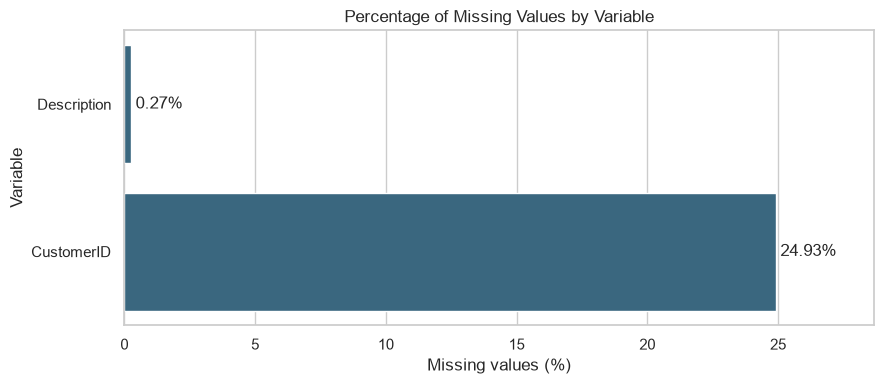

In [11]:
missing_to_plot = missing_summary[
    missing_summary["Missing Count"] > 0
].sort_values("Missing Percentage")

plt.figure(figsize=(9, 4))

ax = sns.barplot(
    data=missing_to_plot.reset_index(),
    x="Missing Percentage",
    y="index",
    color="#2F6B8A"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f%%", padding=3)

plt.title("Percentage of Missing Values by Variable")
plt.xlabel("Missing values (%)")
plt.ylabel("Variable")
plt.xlim(0, missing_to_plot["Missing Percentage"].max() * 1.15)
plt.tight_layout()
plt.show()

In [12]:
missing_customer_id = df["CustomerID"].isna()
missing_description = df["Description"].isna()

missing_overlap_summary = pd.Series({
    "Rows missing CustomerID": missing_customer_id.sum(),
    "Rows missing Description": missing_description.sum(),
    "Rows missing both": (
        missing_customer_id & missing_description
    ).sum(),
    "Rows missing CustomerID only": (
        missing_customer_id & ~missing_description
    ).sum(),
    "Rows missing Description only": (
        ~missing_customer_id & missing_description
    ).sum()
}).to_frame("Row Count")

display(missing_overlap_summary)

,Row Count
Rows missing CustomerID,135080
Rows missing Description,1454
Rows missing both,1454
Rows missing CustomerID only,133626
Rows missing Description only,0


In [14]:
print("Sample rows with missing CustomerID:")
display(df.loc[missing_customer_id].head(10))

print("Sample rows with missing Description:")
display(df.loc[missing_description].head(10))

Sample rows with missing CustomerID:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.00,NaN,United Kingdom
1443,536544,21773,DECORATIVE ROSE BATHROOM BOTTLE,1,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1444,536544,21774,DECORATIVE CATS BATHROOM BOTTLE,2,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1445,536544,21786,POLKADOT RAIN HAT,4,2010-12-01 14:32:00,0.85,NaN,United Kingdom
1446,536544,21787,RAIN PONCHO RETROSPOT,2,2010-12-01 14:32:00,1.66,NaN,United Kingdom
1447,536544,21790,VINTAGE SNAP CARDS,9,2010-12-01 14:32:00,1.66,NaN,United Kingdom
1448,536544,21791,VINTAGE HEADS AND TAILS CARD GAME,2,2010-12-01 14:32:00,2.51,NaN,United Kingdom
1449,536544,21801,CHRISTMAS TREE DECORATION WITH BELL,10,2010-12-01 14:32:00,0.43,NaN,United Kingdom
1450,536544,21802,CHRISTMAS TREE HEART DECORATION,9,2010-12-01 14:32:00,0.43,NaN,United Kingdom
1451,536544,21803,CHRISTMAS TREE STAR DECORATION,11,2010-12-01 14:32:00,0.43,NaN,United Kingdom


Sample rows with missing Description:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.00,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.00,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.00,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.00,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.00,NaN,United Kingdom
1988,536550,85044,NaN,1,2010-12-01 14:34:00,0.00,NaN,United Kingdom
2024,536552,20950,NaN,1,2010-12-01 14:34:00,0.00,NaN,United Kingdom
2025,536553,37461,NaN,3,2010-12-01 14:35:00,0.00,NaN,United Kingdom
2026,536554,84670,NaN,23,2010-12-01 14:35:00,0.00,NaN,United Kingdom
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.00,NaN,United Kingdom


### Missing-Value Interpretation

The missing-value analysis shows that `CustomerID` has substantial missingness, while only a small proportion of `Description` values are missing.

Rows without `CustomerID` cannot contribute to customer segmentation or segment-specific association analysis because they cannot be assigned to an identified customer. However, they should not be deleted from the raw dataset, and their possible use in overall transaction or product analysis must be considered separately.

Rows with missing `Description` require further investigation using their `StockCode`, quantity, price and invoice characteristics before deciding whether they should be excluded.

The raw data therefore remains unchanged. Final handling decisions will be documented with reasons and before-and-after row counts during preprocessing.

## 2. Duplicate-Record Analysis

Exact duplicate rows are investigated before removal. A repeated `InvoiceNo` alone is not a duplicate because one invoice normally contains multiple product lines. An exact duplicate means that all eight column values are repeated.

In [15]:
duplicate_mask = df.duplicated(keep="first")
all_duplicate_occurrences_mask = df.duplicated(keep=False)

duplicate_summary = pd.Series({
    "Total rows": len(df),
    "Additional exact duplicate rows": duplicate_mask.sum(),
    "All rows participating in duplicate groups": (
        all_duplicate_occurrences_mask.sum()
    ),
    "Rows remaining after exact deduplication": (
        len(df) - duplicate_mask.sum()
    ),
    "Duplicate percentage": (
        duplicate_mask.mean() * 100
    )
}).to_frame("Value")

display(duplicate_summary)

,Value
Total rows,"541,909.00"
Additional exact duplicate rows,"5,268.00"
All rows participating in duplicate groups,"10,147.00"
Rows remaining after exact deduplication,"536,641.00"
Duplicate percentage,0.97


In [16]:
duplicate_examples = (
    df.loc[all_duplicate_occurrences_mask]
      .sort_values(
          ["InvoiceNo", "StockCode", "InvoiceDate"],
          kind="stable"
      )
)

print(f"Rows shown from duplicate groups: {len(duplicate_examples):,}")
display(duplicate_examples.head(20))

Rows shown from duplicate groups: 10,147


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,"17,908.00",United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,"17,908.00",United Kingdom
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,"17,908.00",United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,"17,908.00",United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,"17,908.00",United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,"17,908.00",United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,"17,908.00",United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,"17,908.00",United Kingdom
565,536412,21448,12 DAISY PEGS IN WOOD BOX,2,2010-12-01 11:49:00,1.65,"17,920.00",United Kingdom
578,536412,21448,12 DAISY PEGS IN WOOD BOX,1,2010-12-01 11:49:00,1.65,"17,920.00",United Kingdom


In [17]:
duplicate_group_counts = (
    df.groupby(list(df.columns), dropna=False)
      .size()
      .reset_index(name="Occurrence Count")
      .query("`Occurrence Count` > 1")
      .sort_values("Occurrence Count", ascending=False)
)

print(f"Number of exact duplicate groups: {len(duplicate_group_counts):,}")
display(duplicate_group_counts.head(10))

Number of exact duplicate groups: 4,879


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Occurrence Count
207580,555524,22698,PINK REGENCY TEACUP AND SAUCER,1,2011-06-05 11:37:00,2.95,"16,923.00",United Kingdom,20
207579,555524,22697,GREEN REGENCY TEACUP AND SAUCER,1,2011-06-05 11:37:00,2.95,"16,923.00",United Kingdom,12
408646,572861,22775,PURPLE DRAWERKNOB ACRYLIC EDWARDIAN,12,2011-10-26 12:46:00,1.25,"14,102.00",United Kingdom,8
481780,578289,23395,BELLE JARDINIERE CUSHION COVER,1,2011-11-23 14:07:00,3.75,"17,841.00",United Kingdom,6
57332,541266,21754,HOME BUILDING BLOCK WORD,1,2011-01-16 16:25:00,5.95,"15,673.00",United Kingdom,6
57333,541266,21755,LOVE BUILDING BLOCK WORD,1,2011-01-16 16:25:00,5.95,"15,673.00",United Kingdom,6
48190,540524,21756,BATH BUILDING BLOCK WORD,1,2011-01-09 12:53:00,5.95,"16,735.00",United Kingdom,6
403109,572344,M,Manual,48,2011-10-24 10:43:00,1.50,"14,607.00",United Kingdom,6
25692,538514,21756,BATH BUILDING BLOCK WORD,1,2010-12-12 14:27:00,5.95,"15,044.00",United Kingdom,6
9744,537224,70007,HI TEC ALPINE HAND WARMER,1,2010-12-05 16:24:00,1.65,"13,174.00",United Kingdom,5


In [18]:
deduplicated_preview = df.drop_duplicates().copy()

print(f"Rows before deduplication : {len(df):,}")
print(f"Rows removed              : {len(df) - len(deduplicated_preview):,}")
print(f"Rows after deduplication  : {len(deduplicated_preview):,}")
print(
    "Duplicates remaining     : "
    f"{deduplicated_preview.duplicated().sum():,}"
)

# Confirm that the working raw-data copy remains unchanged.
print(f"Original working rows     : {len(df):,}")

Rows before deduplication : 541,909
Rows removed              : 5,268
Rows after deduplication  : 536,641
Duplicates remaining     : 0
Original working rows     : 541,909


### Duplicate-Record Interpretation

The dataset contains exact duplicates across all eight variables. Repeated invoice numbers alone were not treated as duplicates because each invoice can legitimately contain several product lines.

Exact duplicate records would count the same transaction line more than once, potentially inflating quantities, monetary values, product frequencies and association-rule support. Therefore, one copy of each exact record will be retained during preprocessing.

At this stage, `drop_duplicates()` was applied only to a temporary preview. The raw dataset and the main EDA dataframe remain unchanged. The number of removed rows will be recorded in the preprocessing audit.

## 3. Transaction Validity, Cancellations and Returns

According to the dataset documentation, an `InvoiceNo` beginning with `C` represents a cancellation. Negative quantities may indicate returned or reversed transactions. Zero or negative prices cannot contribute valid positive sales revenue and therefore require separate investigation.

In [19]:
is_cancellation = (
    df["InvoiceNo"]
    .astype(str)
    .str.strip()
    .str.upper()
    .str.startswith("C", na=False)
)

is_negative_quantity = df["Quantity"] < 0
is_zero_quantity = df["Quantity"] == 0
is_non_positive_quantity = df["Quantity"] <= 0

is_negative_price = df["UnitPrice"] < 0
is_zero_price = df["UnitPrice"] == 0
is_non_positive_price = df["UnitPrice"] <= 0

transaction_quality_summary = pd.Series({
    "Cancellation rows": is_cancellation.sum(),
    "Negative-quantity rows": is_negative_quantity.sum(),
    "Zero-quantity rows": is_zero_quantity.sum(),
    "Non-positive-quantity rows": is_non_positive_quantity.sum(),
    "Negative-price rows": is_negative_price.sum(),
    "Zero-price rows": is_zero_price.sum(),
    "Non-positive-price rows": is_non_positive_price.sum()
}).to_frame("Row Count")

transaction_quality_summary["Percentage"] = (
    transaction_quality_summary["Row Count"] / len(df) * 100
).round(2)

display(transaction_quality_summary)

,Row Count,Percentage
Cancellation rows,9288,1.71
Negative-quantity rows,10624,1.96
Zero-quantity rows,0,0.00
Non-positive-quantity rows,10624,1.96
Negative-price rows,2,0.00
Zero-price rows,2515,0.46
Non-positive-price rows,2517,0.46


In [20]:
cancellation_quantity_crosstab = pd.crosstab(
    is_cancellation,
    is_negative_quantity,
    rownames=["Cancellation Invoice"],
    colnames=["Negative Quantity"],
    margins=True
)

display(cancellation_quantity_crosstab)

print(
    "Cancellation rows with negative quantity:",
    (is_cancellation & is_negative_quantity).sum()
)

print(
    "Negative-quantity rows without a C-prefixed invoice:",
    (~is_cancellation & is_negative_quantity).sum()
)

print(
    "C-prefixed rows without a negative quantity:",
    (is_cancellation & ~is_negative_quantity).sum()
)

Negative Quantity,False,True,All
Cancellation Invoice,,,
False,531285,1336,532621
True,0,9288,9288
All,531285,10624,541909


Cancellation rows with negative quantity: 9288
Negative-quantity rows without a C-prefixed invoice: 1336
C-prefixed rows without a negative quantity: 0


In [21]:
invoice_summary = pd.Series({
    "Unique invoices": df["InvoiceNo"].nunique(),
    "Unique cancellation invoices": (
        df.loc[is_cancellation, "InvoiceNo"].nunique()
    ),
    "Unique non-cancellation invoices": (
        df.loc[~is_cancellation, "InvoiceNo"].nunique()
    ),
    "Invoices containing negative quantities": (
        df.loc[is_negative_quantity, "InvoiceNo"].nunique()
    )
}).to_frame("Count")

display(invoice_summary)

,Count
Unique invoices,25900
Unique cancellation invoices,3836
Unique non-cancellation invoices,22064
Invoices containing negative quantities,5172


In [22]:
print("Sample cancellation transactions:")
display(df.loc[is_cancellation].head(10))

print("Sample negative quantities without C-prefixed invoices:")
display(df.loc[~is_cancellation & is_negative_quantity].head(10))

print("Sample zero or negative prices:")
display(df.loc[is_non_positive_price].head(10))

Sample cancellation transactions:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,"14,527.00",United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,"15,311.00",United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,"17,548.00",United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,"17,548.00",United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,"17,548.00",United Kingdom
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29,"17,548.00",United Kingdom
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,2010-12-01 10:24:00,3.45,"17,548.00",United Kingdom
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,2010-12-01 10:24:00,1.65,"17,548.00",United Kingdom
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,2010-12-01 10:24:00,1.65,"17,548.00",United Kingdom
939,C536506,22960,JAM MAKING SET WITH JARS,-6,2010-12-01 12:38:00,4.25,"17,897.00",United Kingdom


Sample negative quantities without C-prefixed invoices:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.00,NaN,United Kingdom
4347,536764,84952C,NaN,-38,2010-12-02 14:42:00,0.00,NaN,United Kingdom
7188,536996,22712,NaN,-20,2010-12-03 15:30:00,0.00,NaN,United Kingdom
7189,536997,22028,NaN,-20,2010-12-03 15:30:00,0.00,NaN,United Kingdom
7190,536998,85067,NaN,-6,2010-12-03 15:30:00,0.00,NaN,United Kingdom
7192,537000,21414,NaN,-22,2010-12-03 15:32:00,0.00,NaN,United Kingdom
7193,537001,21653,NaN,-6,2010-12-03 15:33:00,0.00,NaN,United Kingdom
7195,537003,85126,NaN,-2,2010-12-03 15:33:00,0.00,NaN,United Kingdom
7196,537004,21814,NaN,-30,2010-12-03 15:34:00,0.00,NaN,United Kingdom
7197,537005,21692,NaN,-70,2010-12-03 15:35:00,0.00,NaN,United Kingdom


Sample zero or negative prices:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.00,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.00,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.00,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.00,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.00,NaN,United Kingdom
1988,536550,85044,NaN,1,2010-12-01 14:34:00,0.00,NaN,United Kingdom
2024,536552,20950,NaN,1,2010-12-01 14:34:00,0.00,NaN,United Kingdom
2025,536553,37461,NaN,3,2010-12-01 14:35:00,0.00,NaN,United Kingdom
2026,536554,84670,NaN,23,2010-12-01 14:35:00,0.00,NaN,United Kingdom
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.00,NaN,United Kingdom


In [23]:
quality_issue_missing_id_summary = pd.Series({
    "Cancellation rows missing CustomerID": (
        is_cancellation & df["CustomerID"].isna()
    ).sum(),
    "Negative-quantity rows missing CustomerID": (
        is_negative_quantity & df["CustomerID"].isna()
    ).sum(),
    "Non-positive-price rows missing CustomerID": (
        is_non_positive_price & df["CustomerID"].isna()
    ).sum(),
    "Non-positive-price rows missing Description": (
        is_non_positive_price & df["Description"].isna()
    ).sum()
}).to_frame("Row Count")

display(quality_issue_missing_id_summary)

,Row Count
Cancellation rows missing CustomerID,383
Negative-quantity rows missing CustomerID,1719
Non-positive-price rows missing CustomerID,2477
Non-positive-price rows missing Description,1454


### Transaction-Quality Interpretation

Cancellation, return and invalid-price records must not be included directly in purchase-only revenue or RFM calculations because they could reduce or distort customer purchasing measures.

However, these records contain potentially useful information about returns and customer behaviour. Therefore, they will be retained separately for return-related investigation rather than being deleted from the project completely.

A valid purchase-only dataset will later require a non-cancellation invoice, positive quantity and positive unit price. The precise filtering order and its effect on row counts will be documented during preprocessing.

## 4. Numerical, Temporal and Cardinality Analysis

This section examines numerical ranges, transaction coverage and identifier cardinalities before any outlier-handling or filtering decision is made.

In [24]:
numerical_summary = df[
    ["Quantity", "UnitPrice", "CustomerID"]
].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
).T

display(numerical_summary)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
Quantity,"541,909.00",9.55,218.08,"-80,995.00",-2.00,1.00,1.00,3.00,10.00,29.00,100.00,"80,995.00"
UnitPrice,"541,909.00",4.61,96.76,"-11,062.06",0.19,0.42,1.25,2.08,4.13,9.95,18.00,"38,970.00"
CustomerID,"406,829.00","15,287.69","1,713.60","12,346.00","12,415.00","12,626.00","13,953.00","15,152.00","16,791.00","17,905.00","18,212.00","18,287.00"


In [25]:
print("Record with minimum Quantity:")
display(df.loc[[df["Quantity"].idxmin()]])

print("Record with maximum Quantity:")
display(df.loc[[df["Quantity"].idxmax()]])

print("Record with minimum UnitPrice:")
display(df.loc[[df["UnitPrice"].idxmin()]])

print("Record with maximum UnitPrice:")
display(df.loc[[df["UnitPrice"].idxmax()]])

Record with minimum Quantity:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
540422,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,2011-12-09 09:27:00,2.08,"16,446.00",United Kingdom


Record with maximum Quantity:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,"16,446.00",United Kingdom


Record with minimum UnitPrice:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,"-11,062.06",NaN,United Kingdom


Record with maximum UnitPrice:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
222681,C556445,M,Manual,-1,2011-06-10 15:31:00,"38,970.00","15,098.00",United Kingdom


In [26]:
minimum_date = df["InvoiceDate"].min()
maximum_date = df["InvoiceDate"].max()
coverage_days = (maximum_date - minimum_date).days + 1

date_summary = pd.Series({
    "Earliest transaction": minimum_date,
    "Latest transaction": maximum_date,
    "Calendar-day coverage": coverage_days,
    "Unique transaction dates": df["InvoiceDate"].dt.date.nunique(),
    "Unique year-month periods": df["InvoiceDate"].dt.to_period("M").nunique()
}).to_frame("Value")

display(date_summary)

,Value
Earliest transaction,2010-12-01 08:26:00
Latest transaction,2011-12-09 12:50:00
Calendar-day coverage,374
Unique transaction dates,305
Unique year-month periods,13


In [27]:
cardinality_summary = pd.Series({
    "Unique invoices": df["InvoiceNo"].nunique(),
    "Unique stock codes": df["StockCode"].nunique(),
    "Unique descriptions": df["Description"].nunique(dropna=True),
    "Identified customers": df["CustomerID"].nunique(dropna=True),
    "Countries": df["Country"].nunique()
}).to_frame("Unique Count")

display(cardinality_summary)

,Unique Count
Unique invoices,25900
Unique stock codes,4070
Unique descriptions,4223
Identified customers,4372
Countries,38


In [28]:
valid_purchase_mask = (
    ~is_cancellation
    & (df["Quantity"] > 0)
    & (df["UnitPrice"] > 0)
)

identified_valid_purchase_mask = (
    valid_purchase_mask
    & df["CustomerID"].notna()
)

purchase_eligibility_summary = pd.Series({
    "Raw transaction rows": len(df),
    "Preliminary valid-purchase rows": valid_purchase_mask.sum(),
    "Valid-purchase rows with CustomerID": (
        identified_valid_purchase_mask.sum()
    ),
    "Valid-purchase rows without CustomerID": (
        valid_purchase_mask & df["CustomerID"].isna()
    ).sum(),
    "Rows excluded by purchase-validity rules": (
        ~valid_purchase_mask
    ).sum()
}).to_frame("Row Count")

purchase_eligibility_summary["Percentage of Raw Data"] = (
    purchase_eligibility_summary["Row Count"] / len(df) * 100
).round(2)

display(purchase_eligibility_summary)

,Row Count,Percentage of Raw Data
Raw transaction rows,541909,100.00
Preliminary valid-purchase rows,530104,97.82
Valid-purchase rows with CustomerID,397884,73.42
Valid-purchase rows without CustomerID,132220,24.40
Rows excluded by purchase-validity rules,11805,2.18


### Numerical and Temporal Interpretation

The dataset covers transactions from December 2010 to 09 December 2011. Since December 2011 is incomplete, direct comparison of its monthly totals with complete months may be misleading.

The numerical summary contains extreme quantity and unit-price values. These observations may represent wholesale purchases, returns, accounting adjustments or data-entry anomalies. They will therefore be investigated before choosing retention, transformation or capping strategies.

A preliminary purchase-validity mask was created using non-cancellation invoices, positive quantities and positive unit prices. Customer segmentation will additionally require a non-missing `CustomerID`. This mask has not changed the raw dataframe.

## 5. Extreme-Value and Outlier Investigation

Retail transaction data can contain genuine large wholesale purchases as well as returns, accounting adjustments and data-entry anomalies. Therefore, extreme values are inspected in context before any transformation, capping or removal decision is made.

In [29]:
purchase_audit_df = (
    df.loc[
        valid_purchase_mask,
        [
            "InvoiceNo",
            "StockCode",
            "Description",
            "Quantity",
            "InvoiceDate",
            "UnitPrice",
            "CustomerID",
            "Country"
        ]
    ]
    .drop_duplicates()
    .copy()
)

purchase_audit_df["LineTotal"] = (
    purchase_audit_df["Quantity"]
    * purchase_audit_df["UnitPrice"]
)

print(f"Raw rows                        : {len(df):,}")
print(f"Valid rows before deduplication : {valid_purchase_mask.sum():,}")
print(f"Valid rows after deduplication  : {len(purchase_audit_df):,}")
print(
    "Valid identified-customer rows : "
    f"{purchase_audit_df['CustomerID'].notna().sum():,}"
)

Raw rows                        : 541,909
Valid rows before deduplication : 530,104
Valid rows after deduplication  : 524,878
Valid identified-customer rows : 392,692


In [30]:
purchase_distribution_summary = purchase_audit_df[
    ["Quantity", "UnitPrice", "LineTotal"]
].describe(
    percentiles=[
        0.01, 0.05, 0.25, 0.50,
        0.75, 0.90, 0.95, 0.99, 0.999
    ]
).T

display(purchase_distribution_summary)

,count,mean,std,min,1%,5%,25%,50%,75%,90%,95%,99%,99.9%,max
Quantity,"524,878.00",10.62,156.28,1.00,1.00,1.00,1.00,4.00,11.00,24.00,30.00,100.00,456.00,"80,995.00"
UnitPrice,"524,878.00",3.92,36.09,0.00,0.29,0.42,1.25,2.08,4.13,7.95,9.95,16.98,165.02,"13,541.33"
LineTotal,"524,878.00",20.28,271.69,0.00,0.55,1.25,3.90,9.92,17.70,33.00,59.80,183.60,841.21,"168,469.60"


In [31]:
print("Largest valid purchase lines by quantity:")
display(
    purchase_audit_df.nlargest(10, "Quantity")
    [[
        "InvoiceNo",
        "StockCode",
        "Description",
        "Quantity",
        "UnitPrice",
        "LineTotal",
        "CustomerID",
        "Country"
    ]]
)

print("Largest valid purchase lines by unit price:")
display(
    purchase_audit_df.nlargest(10, "UnitPrice")
    [[
        "InvoiceNo",
        "StockCode",
        "Description",
        "Quantity",
        "UnitPrice",
        "LineTotal",
        "CustomerID",
        "Country"
    ]]
)

print("Largest valid purchase lines by line total:")
display(
    purchase_audit_df.nlargest(10, "LineTotal")
    [[
        "InvoiceNo",
        "StockCode",
        "Description",
        "Quantity",
        "UnitPrice",
        "LineTotal",
        "CustomerID",
        "Country"
    ]]
)

Largest valid purchase lines by quantity:


,InvoiceNo,StockCode,Description,Quantity,UnitPrice,LineTotal,CustomerID,Country
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,"168,469.60","16,446.00",United Kingdom
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,"77,183.60","12,346.00",United Kingdom
421632,573008,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,4800,0.21,"1,008.00","12,901.00",United Kingdom
206121,554868,22197,SMALL POPCORN HOLDER,4300,0.72,"3,096.00","13,135.00",United Kingdom
97432,544612,22053,EMPIRE DESIGN ROSETTE,3906,0.82,"3,202.92","18,087.00",United Kingdom
270885,560599,18007,ESSENTIAL BALM 3.5g TIN IN ENVELOPE,3186,0.06,191.16,"14,609.00",United Kingdom
52711,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,"6,539.40","15,749.00",United Kingdom
160546,550461,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,"6,539.40","15,749.00",United Kingdom
433788,573995,16014,SMALL CHINESE STYLE SCISSOR,3000,0.32,960.00,"16,308.00",United Kingdom
4945,536830,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,2880,0.18,518.40,"16,754.00",United Kingdom


Largest valid purchase lines by unit price:


,InvoiceNo,StockCode,Description,Quantity,UnitPrice,LineTotal,CustomerID,Country
15017,537632,AMAZONFEE,AMAZON FEE,1,"13,541.33","13,541.33",NaN,United Kingdom
299982,A563185,B,Adjust bad debt,1,"11,062.06","11,062.06",NaN,United Kingdom
173382,551697,POST,POSTAGE,1,"8,142.75","8,142.75","16,029.00",United Kingdom
297723,562955,DOT,DOTCOM POSTAGE,1,"4,505.17","4,505.17",NaN,United Kingdom
268028,560373,M,Manual,1,"4,287.63","4,287.63",NaN,United Kingdom
422351,573077,M,Manual,1,"4,161.06","4,161.06","12,536.00",France
422376,573080,M,Manual,1,"4,161.06","4,161.06","12,536.00",France
406406,571751,M,Manual,1,"3,949.32","3,949.32","12,744.00",Singapore
374542,569382,M,Manual,1,"3,155.95","3,155.95","15,502.00",United Kingdom
347948,567353,M,Manual,1,"2,653.95","2,653.95",NaN,Hong Kong


Largest valid purchase lines by line total:


,InvoiceNo,StockCode,Description,Quantity,UnitPrice,LineTotal,CustomerID,Country
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08,"168,469.60","16,446.00",United Kingdom
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04,"77,183.60","12,346.00",United Kingdom
222680,556444,22502,PICNIC BASKET WICKER 60 PIECES,60,649.50,"38,970.00","15,098.00",United Kingdom
15017,537632,AMAZONFEE,AMAZON FEE,1,"13,541.33","13,541.33",NaN,United Kingdom
299982,A563185,B,Adjust bad debt,1,"11,062.06","11,062.06",NaN,United Kingdom
173382,551697,POST,POSTAGE,1,"8,142.75","8,142.75","16,029.00",United Kingdom
348325,567423,23243,SET OF TEA COFFEE SUGAR TINS PANTRY,1412,5.06,"7,144.72","17,450.00",United Kingdom
52711,540815,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,"6,539.40","15,749.00",United Kingdom
160546,550461,21108,FAIRY CAKE FLANNEL ASSORTED COLOUR,3114,2.10,"6,539.40","15,749.00",United Kingdom
421601,573003,23084,RABBIT NIGHT LIGHT,2400,2.08,"4,992.00","14,646.00",Netherlands


In [32]:
def iqr_outlier_summary(data, columns):
    records = []

    for column in columns:
        q1 = data[column].quantile(0.25)
        q3 = data[column].quantile(0.75)
        iqr = q3 - q1
        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        outlier_count = (
            (data[column] < lower_bound)
            | (data[column] > upper_bound)
        ).sum()

        records.append({
            "Variable": column,
            "Q1": q1,
            "Q3": q3,
            "IQR": iqr,
            "Lower Bound": lower_bound,
            "Upper Bound": upper_bound,
            "IQR Outlier Count": outlier_count,
            "Outlier Percentage": round(
                outlier_count / len(data) * 100,
                2
            )
        })

    return pd.DataFrame(records).set_index("Variable")


iqr_summary = iqr_outlier_summary(
    purchase_audit_df,
    ["Quantity", "UnitPrice", "LineTotal"]
)

display(iqr_summary)

,Q1,Q3,IQR,Lower Bound,Upper Bound,IQR Outlier Count,Outlier Percentage
Variable,,,,,,,
Quantity,1.00,11.00,10.00,-14.00,26.00,27111,5.17
UnitPrice,1.25,4.13,2.88,-3.07,8.45,37827,7.21
LineTotal,3.90,17.70,13.80,-16.80,38.40,42624,8.12


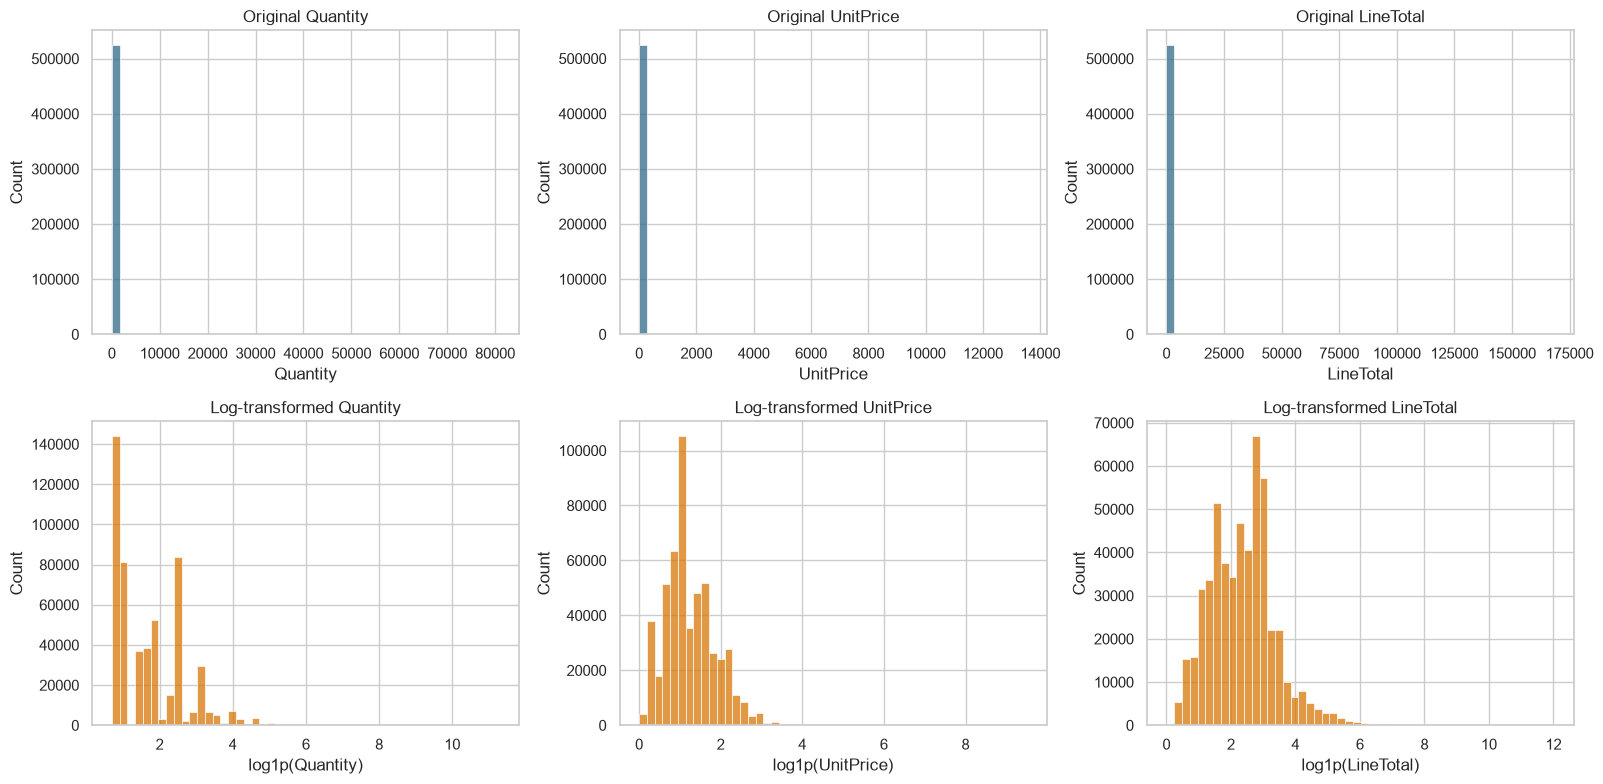

In [33]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))

variables = ["Quantity", "UnitPrice", "LineTotal"]

for index, variable in enumerate(variables):
    sns.histplot(
        purchase_audit_df[variable],
        bins=50,
        ax=axes[0, index],
        color="#2F6B8A"
    )
    axes[0, index].set_title(f"Original {variable}")

    sns.histplot(
        np.log1p(purchase_audit_df[variable]),
        bins=50,
        ax=axes[1, index],
        color="#D97706"
    )
    axes[1, index].set_title(f"Log-transformed {variable}")
    axes[1, index].set_xlabel(f"log1p({variable})")

plt.tight_layout()
plt.show()

### Extreme-Value Interpretation

The purchase variables are strongly right-skewed. The maximum values are substantially larger than the upper percentiles, indicating a small number of highly influential transaction lines.

The IQR method flags observations statistically, but this does not prove that they are errors. Large quantities may represent genuine wholesale purchases, while unusual stock codes or descriptions may represent administrative charges rather than normal products.

Therefore, transaction rows will not be removed solely because they exceed an IQR boundary. Log transformation and sensitivity analysis will be considered for customer-level clustering, while extreme records will be examined using their invoice, product, customer and description context.

## 6. Product-Code and Administrative-Record Investigation

Some stock codes represent postage, fees, discounts, manual adjustments or accounting records rather than merchandise. Including these records in product association rules could produce misleading bundles. Their treatment in customer monetary calculations also requires explicit justification.

In [34]:
stock_code_text = (
    purchase_audit_df["StockCode"]
    .astype(str)
    .str.strip()
    .str.upper()
)

contains_digit = stock_code_text.str.contains(r"\d", regex=True)

non_standard_code_df = purchase_audit_df.loc[
    ~contains_digit
].copy()

print(
    "Valid purchase rows with StockCodes containing no digits:",
    f"{len(non_standard_code_df):,}"
)

print(
    "Unique StockCodes containing no digits:",
    non_standard_code_df["StockCode"].nunique()
)

display(
    non_standard_code_df[
        ["StockCode", "Description"]
    ]
    .drop_duplicates()
    .sort_values(["StockCode", "Description"])
)

Valid purchase rows with StockCodes containing no digits: 2,193
Unique StockCodes containing no digits: 11


,StockCode,Description
15017,AMAZONFEE,AMAZON FEE
299982,B,Adjust bad debt
4406,BANK CHARGES,Bank Charges
84016,DCGSSBOY,BOYS PARTY BAG
84017,DCGSSGIRL,GIRLS PARTY BAG
1814,DOT,DOTCOM POSTAGE
2239,M,Manual
157195,PADS,PADS TO MATCH ALL CUSHIONS
45,POST,POSTAGE
152709,S,SAMPLES


In [35]:
non_standard_code_summary = (
    non_standard_code_df
    .groupby(["StockCode", "Description"], dropna=False)
    .agg(
        Row_Count=("InvoiceNo", "size"),
        Invoice_Count=("InvoiceNo", "nunique"),
        Customer_Count=("CustomerID", "nunique"),
        Total_Quantity=("Quantity", "sum"),
        Total_Value=("LineTotal", "sum"),
        Missing_CustomerID=("CustomerID", lambda x: x.isna().sum())
    )
    .reset_index()
    .sort_values("Total_Value", ascending=False)
)

display(non_standard_code_summary)

,StockCode,Description,Row_Count,Invoice_Count,Customer_Count,Total_Quantity,Total_Value,Missing_CustomerID
5,DOT,DOTCOM POSTAGE,706,706,1,706,"206,248.77",690
8,POST,POSTAGE,1126,1126,331,3150,"78,101.88",27
6,M,Manual,316,289,197,6984,"77,750.27",37
0,AMAZONFEE,AMAZON FEE,2,2,0,2,"13,761.09",2
1,B,Adjust bad debt,1,1,0,1,"11,062.06",1
2,BANK CHARGES,Bank Charges,12,11,10,12,165.00,0
3,DCGSSBOY,BOYS PARTY BAG,11,11,0,47,150.55,11
4,DCGSSGIRL,GIRLS PARTY BAG,13,13,0,47,144.43,13
9,S,SAMPLES,2,2,0,2,63.05,2
10,m,Manual,1,1,0,1,2.55,1


In [36]:
candidate_administrative_codes = {
    "AMAZONFEE",
    "B",
    "BANK CHARGES",
    "C2",
    "CRUK",
    "D",
    "DOT",
    "M",
    "PADS",
    "POST",
    "S",
    "TEST001",
    "TEST002"
}

is_candidate_administrative = stock_code_text.isin(
    candidate_administrative_codes
)

administrative_summary = pd.Series({
    "Candidate administrative rows": (
        is_candidate_administrative.sum()
    ),
    "Candidate administrative invoices": (
        purchase_audit_df.loc[
            is_candidate_administrative,
            "InvoiceNo"
        ].nunique()
    ),
    "Candidate administrative total value": (
        purchase_audit_df.loc[
            is_candidate_administrative,
            "LineTotal"
        ].sum()
    ),
    "Candidate administrative rows missing CustomerID": (
        purchase_audit_df.loc[
            is_candidate_administrative,
            "CustomerID"
        ].isna().sum()
    )
}).to_frame("Value")

display(administrative_summary)

,Value
Candidate administrative rows,"2,310.00"
Candidate administrative invoices,"2,279.00"
Candidate administrative total value,"394,205.67"
Candidate administrative rows missing CustomerID,768.00


In [37]:
merchandise_candidate_df = purchase_audit_df.loc[
    ~is_candidate_administrative
].copy()

product_eligibility_summary = pd.Series({
    "Valid deduplicated purchase rows": len(purchase_audit_df),
    "Candidate administrative rows": is_candidate_administrative.sum(),
    "Candidate merchandise rows": len(merchandise_candidate_df),
    "Unique codes before exclusion": (
        purchase_audit_df["StockCode"].nunique()
    ),
    "Unique codes after candidate exclusion": (
        merchandise_candidate_df["StockCode"].nunique()
    ),
    "Invoices after candidate exclusion": (
        merchandise_candidate_df["InvoiceNo"].nunique()
    )
}).to_frame("Count")

display(product_eligibility_summary)

,Count
Valid deduplicated purchase rows,524878
Candidate administrative rows,2310
Candidate merchandise rows,522568
Unique codes before exclusion,3922
Unique codes after candidate exclusion,3912
Invoices after candidate exclusion,19773


### Product-Code Interpretation

The inspection identified several stock codes representing fees, postage, discounts, manual entries and accounting adjustments rather than physical merchandise.

These administrative records should be excluded from product association-rule mining because they are not meaningful products to bundle or recommend. Otherwise, the model could generate rules involving items such as postage or manual charges.

Their exclusion from customer monetary-value calculations is not automatic. Customer segmentation results should be compared with and without high-impact administrative records because some charges may represent genuine customer expenditure, while others are internal accounting adjustments.

The list of administrative codes is treated as a candidate rule and will be validated using code descriptions and sensitivity analysis before final preprocessing.

In [38]:
print("NON-STANDARD STOCK CODES")
print("-" * 50)

non_standard_pairs = (
    non_standard_code_df[["StockCode", "Description"]]
    .drop_duplicates()
    .sort_values(["StockCode", "Description"])
)

for _, row in non_standard_pairs.iterrows():
    print(f"{str(row['StockCode']):<15} | {row['Description']}")

print("\nADMINISTRATIVE-CODE SUMMARY")
print("-" * 50)
print(
    f"Administrative rows           : "
    f"{is_candidate_administrative.sum():,}"
)
print(
    f"Administrative invoices       : "
    f"{purchase_audit_df.loc[is_candidate_administrative, 'InvoiceNo'].nunique():,}"
)
print(
    f"Administrative total value    : £"
    f"{purchase_audit_df.loc[is_candidate_administrative, 'LineTotal'].sum():,.2f}"
)
print(
    f"Rows missing CustomerID       : "
    f"{purchase_audit_df.loc[is_candidate_administrative, 'CustomerID'].isna().sum():,}"
)

print("\nMERCHANDISE-CANDIDATE SUMMARY")
print("-" * 50)
print(f"Valid deduplicated rows       : {len(purchase_audit_df):,}")
print(
    f"Candidate merchandise rows    : "
    f"{len(merchandise_candidate_df):,}"
)
print(
    f"Unique codes before exclusion : "
    f"{purchase_audit_df['StockCode'].nunique():,}"
)
print(
    f"Unique codes after exclusion  : "
    f"{merchandise_candidate_df['StockCode'].nunique():,}"
)
print(
    f"Invoices after exclusion      : "
    f"{merchandise_candidate_df['InvoiceNo'].nunique():,}"
)

NON-STANDARD STOCK CODES
--------------------------------------------------
AMAZONFEE       | AMAZON FEE
B               | Adjust bad debt
BANK CHARGES    | Bank Charges
DCGSSBOY        | BOYS PARTY BAG
DCGSSGIRL       | GIRLS PARTY BAG
DOT             | DOTCOM POSTAGE
M               | Manual
PADS            | PADS TO MATCH ALL CUSHIONS
POST            | POSTAGE
S               | SAMPLES
m               | Manual

ADMINISTRATIVE-CODE SUMMARY
--------------------------------------------------
Administrative rows           : 2,310
Administrative invoices       : 2,279
Administrative total value    : £394,205.67
Rows missing CustomerID       : 768

MERCHANDISE-CANDIDATE SUMMARY
--------------------------------------------------
Valid deduplicated rows       : 524,878
Candidate merchandise rows    : 522,568
Unique codes before exclusion : 3,922
Unique codes after exclusion  : 3,912
Invoices after exclusion      : 19,773


## 7. Geographic Distribution

The geographic distribution is examined to determine whether the dataset represents a balanced international customer base or is dominated by the retailer's primary UK market.

In [39]:
country_summary = (
    purchase_audit_df
    .groupby("Country", dropna=False)
    .agg(
        Transaction_Rows=("InvoiceNo", "size"),
        Unique_Invoices=("InvoiceNo", "nunique"),
        Identified_Customers=("CustomerID", "nunique"),
        Total_Quantity=("Quantity", "sum"),
        Total_Revenue=("LineTotal", "sum")
    )
    .reset_index()
    .sort_values("Total_Revenue", ascending=False)
)

country_summary["Row_Percentage"] = (
    country_summary["Transaction_Rows"]
    / country_summary["Transaction_Rows"].sum()
    * 100
).round(2)

country_summary["Revenue_Percentage"] = (
    country_summary["Total_Revenue"]
    / country_summary["Total_Revenue"].sum()
    * 100
).round(2)

display(country_summary.head(15))

,Country,Transaction_Rows,Unique_Invoices,Identified_Customers,Total_Quantity,Total_Revenue,Row_Percentage,Revenue_Percentage
36,United Kingdom,479985,18019,3920,4646906,"9,001,744.09",91.45,84.59
24,Netherlands,2359,94,9,200361,"285,446.34",0.45,2.68
10,EIRE,7879,288,3,147007,"283,140.52",1.50,2.66
14,Germany,9025,457,94,119154,"228,678.40",1.72,2.15
13,France,8392,392,87,112060,"209,625.37",1.60,1.97
0,Australia,1181,57,9,83891,"138,453.81",0.23,1.30
31,Spain,2479,90,30,27933,"61,558.56",0.47,0.58
33,Switzerland,1958,54,21,30617,"57,067.60",0.37,0.54
3,Belgium,2031,98,25,23237,"41,196.34",0.39,0.39
32,Sweden,450,36,8,36078,"38,367.83",0.09,0.36


In [40]:
uk_mask = purchase_audit_df["Country"].eq("United Kingdom")

uk_summary = pd.Series({
    "UK valid purchase rows": uk_mask.sum(),
    "UK row percentage": uk_mask.mean() * 100,
    "UK unique invoices": (
        purchase_audit_df.loc[uk_mask, "InvoiceNo"].nunique()
    ),
    "UK identified customers": (
        purchase_audit_df.loc[uk_mask, "CustomerID"].nunique()
    ),
    "UK total revenue": (
        purchase_audit_df.loc[uk_mask, "LineTotal"].sum()
    ),
    "UK revenue percentage": (
        purchase_audit_df.loc[uk_mask, "LineTotal"].sum()
        / purchase_audit_df["LineTotal"].sum()
        * 100
    ),
    "Non-UK valid purchase rows": (~uk_mask).sum(),
    "Non-UK identified customers": (
        purchase_audit_df.loc[~uk_mask, "CustomerID"].nunique()
    )
}).to_frame("Value")

display(uk_summary)

,Value
UK valid purchase rows,"479,985.00"
UK row percentage,91.45
UK unique invoices,"18,019.00"
UK identified customers,"3,920.00"
UK total revenue,"9,001,744.09"
UK revenue percentage,84.59
Non-UK valid purchase rows,"44,893.00"
Non-UK identified customers,418.00


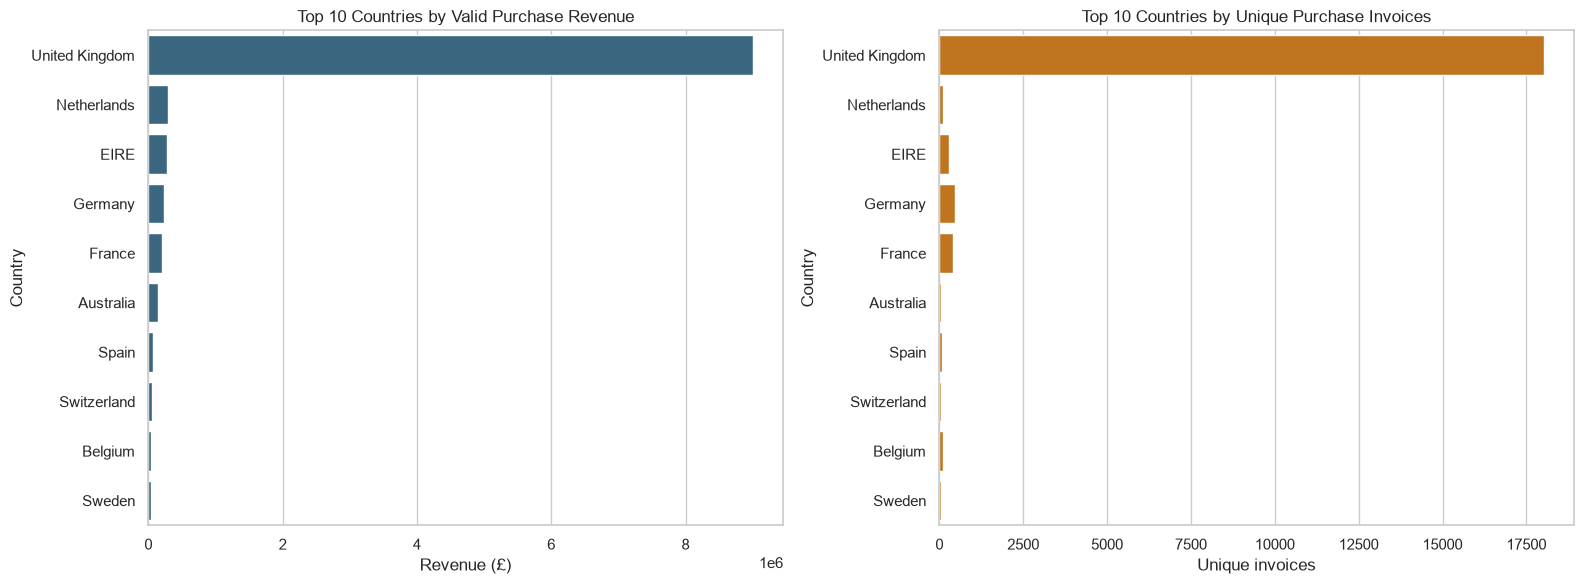

In [41]:
top_countries = country_summary.head(10).copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(
    data=top_countries,
    x="Total_Revenue",
    y="Country",
    ax=axes[0],
    color="#2F6B8A"
)
axes[0].set_title("Top 10 Countries by Valid Purchase Revenue")
axes[0].set_xlabel("Revenue (£)")
axes[0].set_ylabel("Country")

sns.barplot(
    data=top_countries,
    x="Unique_Invoices",
    y="Country",
    ax=axes[1],
    color="#D97706"
)
axes[1].set_title("Top 10 Countries by Unique Purchase Invoices")
axes[1].set_xlabel("Unique invoices")
axes[1].set_ylabel("Country")

plt.tight_layout()
plt.show()

In [42]:
geographic_customer_summary = (
    purchase_audit_df.loc[
        purchase_audit_df["CustomerID"].notna()
    ]
    .assign(
        Market=lambda data: np.where(
            data["Country"].eq("United Kingdom"),
            "United Kingdom",
            "Non-UK"
        )
    )
    .groupby("Market")
    .agg(
        Transaction_Rows=("InvoiceNo", "size"),
        Unique_Invoices=("InvoiceNo", "nunique"),
        Identified_Customers=("CustomerID", "nunique"),
        Total_Revenue=("LineTotal", "sum")
    )
)

display(geographic_customer_summary)

,Transaction_Rows,Unique_Invoices,Identified_Customers,Total_Revenue
Market,,,,
Non-UK,43489,1886,418,"1,602,184.25"
United Kingdom,349203,16646,3920,"7,285,024.64"


### Geographic Interpretation

The country-level analysis is used to measure the dominance of the United Kingdom in transaction rows, customers, invoices and revenue.

If the UK represents a very large majority of observations, clustering all customers together may cause the resulting segments to reflect mainly UK purchasing behaviour. Country should not automatically be encoded as a distance-based clustering feature because the project is primarily based on customer purchasing behaviour and the geographic distribution is highly imbalanced.

The final analysis should report this geographic limitation. A UK-only sensitivity analysis may also be compared with the full identified-customer dataset if country-level purchasing patterns appear materially different.

## 8. Temporal Patterns and Seasonality

Monthly purchasing activity is examined using valid deduplicated purchase records. The final month requires special attention because the dataset ends on 09 December 2011 and therefore does not represent a complete calendar month.

In [43]:
temporal_df = purchase_audit_df.copy()

temporal_df["Month"] = (
    temporal_df["InvoiceDate"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

monthly_summary = (
    temporal_df
    .groupby("Month")
    .agg(
        Transaction_Rows=("InvoiceNo", "size"),
        Unique_Invoices=("InvoiceNo", "nunique"),
        Identified_Customers=("CustomerID", "nunique"),
        Total_Quantity=("Quantity", "sum"),
        Total_Revenue=("LineTotal", "sum"),
        First_Transaction=("InvoiceDate", "min"),
        Last_Transaction=("InvoiceDate", "max")
    )
    .reset_index()
)

monthly_summary["Observed_Days"] = (
    monthly_summary["Last_Transaction"].dt.day
    - monthly_summary["First_Transaction"].dt.day
    + 1
)

final_month = monthly_summary["Month"].max()

monthly_summary["Partial_Final_Month"] = (
    monthly_summary["Month"] == final_month
)

display(monthly_summary)

,Month,Transaction_Rows,Unique_Invoices,Identified_Customers,Total_Quantity,Total_Revenue,First_Transaction,Last_Transaction,Observed_Days,Partial_Final_Month
0,2010-12-01,40991,1559,885,358019,"821,452.73",2010-12-01 08:26:00,2010-12-23 17:41:00,23,False
1,2011-01-01,34060,1086,741,387099,"689,811.61",2011-01-04 10:00:00,2011-01-31 16:59:00,28,False
2,2011-02-01,26882,1100,758,282934,"522,545.56",2011-02-01 08:23:00,2011-02-28 17:01:00,28,False
3,2011-03-01,35497,1454,974,376599,"716,215.26",2011-03-01 08:30:00,2011-03-31 19:55:00,31,False
4,2011-04-01,28882,1246,856,307953,"536,968.49",2011-04-01 08:22:00,2011-04-28 19:53:00,28,False
5,2011-05-01,35917,1681,1056,395001,"769,296.61",2011-05-01 10:51:00,2011-05-31 15:53:00,31,False
6,2011-06-01,35716,1533,991,388511,"760,547.01",2011-06-01 07:37:00,2011-06-30 20:08:00,30,False
7,2011-07-01,38395,1475,949,399693,"718,076.12",2011-07-01 08:16:00,2011-07-31 16:04:00,31,False
8,2011-08-01,34264,1361,935,421020,"757,841.38",2011-08-01 08:30:00,2011-08-31 17:30:00,31,False
9,2011-09-01,48900,1837,1266,569573,"1,056,435.19",2011-09-01 08:25:00,2011-09-30 17:22:00,30,False


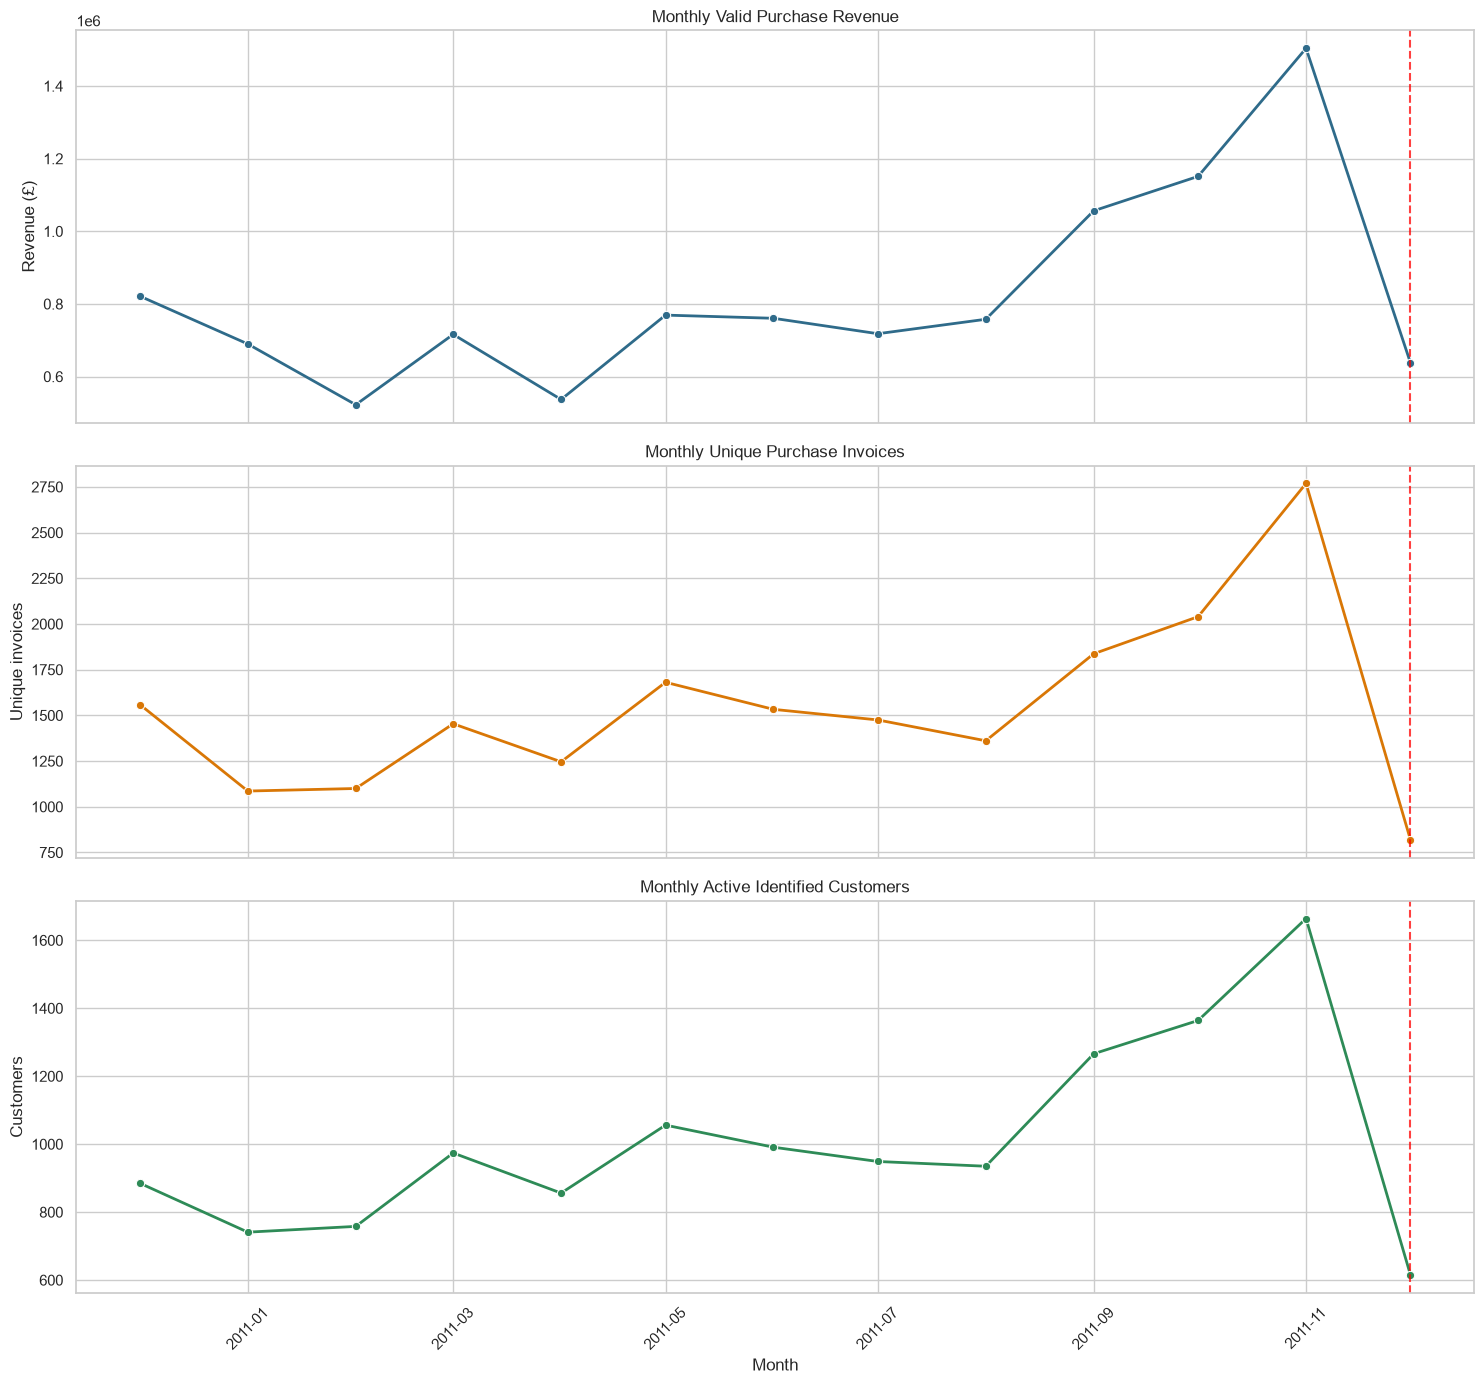

In [44]:
fig, axes = plt.subplots(3, 1, figsize=(15, 14), sharex=True)

sns.lineplot(
    data=monthly_summary,
    x="Month",
    y="Total_Revenue",
    marker="o",
    linewidth=2,
    ax=axes[0],
    color="#2F6B8A"
)
axes[0].set_title("Monthly Valid Purchase Revenue")
axes[0].set_ylabel("Revenue (£)")
axes[0].set_xlabel("")

sns.lineplot(
    data=monthly_summary,
    x="Month",
    y="Unique_Invoices",
    marker="o",
    linewidth=2,
    ax=axes[1],
    color="#D97706"
)
axes[1].set_title("Monthly Unique Purchase Invoices")
axes[1].set_ylabel("Unique invoices")
axes[1].set_xlabel("")

sns.lineplot(
    data=monthly_summary,
    x="Month",
    y="Identified_Customers",
    marker="o",
    linewidth=2,
    ax=axes[2],
    color="#2E8B57"
)
axes[2].set_title("Monthly Active Identified Customers")
axes[2].set_ylabel("Customers")
axes[2].set_xlabel("Month")

for axis in axes:
    axis.axvline(
        final_month,
        color="red",
        linestyle="--",
        alpha=0.75
    )

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [45]:
complete_months = monthly_summary.loc[
    ~monthly_summary["Partial_Final_Month"]
].copy()

highest_revenue_month = complete_months.loc[
    complete_months["Total_Revenue"].idxmax()
]

lowest_revenue_month = complete_months.loc[
    complete_months["Total_Revenue"].idxmin()
]

print("Highest-revenue complete month")
print("-" * 40)
print(f"Month            : {highest_revenue_month['Month']:%Y-%m}")
print(f"Revenue          : £{highest_revenue_month['Total_Revenue']:,.2f}")
print(f"Unique invoices  : {highest_revenue_month['Unique_Invoices']:,}")
print(f"Active customers : {highest_revenue_month['Identified_Customers']:,}")

print("\nLowest-revenue complete month")
print("-" * 40)
print(f"Month            : {lowest_revenue_month['Month']:%Y-%m}")
print(f"Revenue          : £{lowest_revenue_month['Total_Revenue']:,.2f}")
print(f"Unique invoices  : {lowest_revenue_month['Unique_Invoices']:,}")
print(f"Active customers : {lowest_revenue_month['Identified_Customers']:,}")

Highest-revenue complete month
----------------------------------------
Month            : 2011-11
Revenue          : £1,503,866.78
Unique invoices  : 2,769
Active customers : 1,664

Lowest-revenue complete month
----------------------------------------
Month            : 2011-02
Revenue          : £522,545.56
Unique invoices  : 1,100
Active customers : 758


In [46]:
final_month_summary = monthly_summary.loc[
    monthly_summary["Partial_Final_Month"]
].iloc[0]

print(f"Final month              : {final_month_summary['Month']:%Y-%m}")
print(
    "First observed datetime :",
    final_month_summary["First_Transaction"]
)
print(
    "Last observed datetime  :",
    final_month_summary["Last_Transaction"]
)
print(
    "Observed calendar span  :",
    f"{final_month_summary['Observed_Days']} days"
)
print(
    "Final month is partial  :",
    final_month_summary["Partial_Final_Month"]
)

Final month              : 2011-12
First observed datetime : 2011-12-01 08:33:00
Last observed datetime  : 2011-12-09 12:50:00
Observed calendar span  : 9 days
Final month is partial  : True


### Temporal Interpretation

Monthly revenue, invoice activity and active-customer counts vary throughout the observation period. These changes may reflect seasonality, customer demand, wholesale orders and the influence of unusually large transactions.

December 2011 contains records only up to 09 December and is therefore an incomplete month. Its total revenue, invoice count and active-customer count must not be directly compared with totals from complete months.

The incomplete final month does not prevent calculation of customer recency. A fixed analysis date of one day after the latest transaction will later be used consistently. However, conclusions about monthly seasonality must explicitly identify December 2011 as partial.

## 9. Product Performance and Description Consistency

Product performance is analysed using candidate merchandise records only. Administrative codes such as postage, fees and manual adjustments are excluded from this section because they are not products that can be recommended or bundled.

`StockCode` is used as the stable product identifier. Product descriptions are investigated because one stock code may have spelling, formatting or naming variations.

In [47]:
def most_common_description(series):
    """Return the most frequently occurring non-missing description."""
    cleaned = series.dropna().astype(str).str.strip()

    if cleaned.empty:
        return np.nan

    modes = cleaned.mode()
    return modes.iloc[0]


product_summary = (
    merchandise_candidate_df
    .groupby("StockCode")
    .agg(
        Canonical_Description=(
            "Description",
            most_common_description
        ),
        Transaction_Rows=("InvoiceNo", "size"),
        Unique_Invoices=("InvoiceNo", "nunique"),
        Identified_Customers=("CustomerID", "nunique"),
        Total_Quantity=("Quantity", "sum"),
        Total_Revenue=("LineTotal", "sum"),
        Median_UnitPrice=("UnitPrice", "median")
    )
    .reset_index()
)

print(f"Candidate merchandise products: {len(product_summary):,}")
display(product_summary.head())

Candidate merchandise products: 3,912


,StockCode,Canonical_Description,Transaction_Rows,Unique_Invoices,Identified_Customers,Total_Quantity,Total_Revenue,Median_UnitPrice
0,10002,INFLATABLE POLITICAL GLOBE,71,71,40,860,759.89,0.85
1,10080,GROOVY CACTUS INFLATABLE,22,22,19,303,119.09,0.39
2,10120,DOGGY RUBBER,29,29,25,192,40.32,0.21
3,10125,MINI FUNKY DESIGN TAPES,93,91,49,1295,993.99,0.85
4,10133,COLOURING PENCILS BROWN TUBE,196,196,101,2856,"1,539.60",0.79


In [48]:
top_products_quantity = (
    product_summary
    .nlargest(15, "Total_Quantity")
    [[
        "StockCode",
        "Canonical_Description",
        "Total_Quantity",
        "Total_Revenue",
        "Unique_Invoices",
        "Identified_Customers"
    ]]
)

display(top_products_quantity)

,StockCode,Canonical_Description,Total_Quantity,Total_Revenue,Unique_Invoices,Identified_Customers
2390,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,"168,469.60",1,1
1945,23166,MEDIUM CERAMIC TOP STORAGE JAR,78033,"81,700.92",247,138
1034,22197,POPCORN HOLDER,56898,"51,334.47",1392,407
2562,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,54951,"13,814.01",535,307
3528,85099B,JUMBO BAG RED RETROSPOT,48371,"94,159.81",2089,635
3539,85123A,WHITE HANGING HEART T-LIGHT HOLDER,37641,"104,462.75",2198,856
364,21212,PACK OF 72 RETROSPOT CAKE CASES,36396,"21,246.45",1320,635
2666,84879,ASSORTED COLOUR BIRD ORNAMENT,36362,"58,927.62",1455,678
1867,23084,RABBIT NIGHT LIGHT,30739,"66,870.03",994,450
1299,22492,MINI PAINT SET VINTAGE,26633,"16,937.82",380,213


In [49]:
top_products_revenue = (
    product_summary
    .nlargest(15, "Total_Revenue")
    [[
        "StockCode",
        "Canonical_Description",
        "Total_Revenue",
        "Total_Quantity",
        "Unique_Invoices",
        "Identified_Customers"
    ]]
)

display(top_products_revenue)

,StockCode,Canonical_Description,Total_Revenue,Total_Quantity,Unique_Invoices,Identified_Customers
1235,22423,REGENCY CAKESTAND 3 TIER,"174,156.54",13851,1988,881
2390,23843,"PAPER CRAFT , LITTLE BIRDIE","168,469.60",80995,1,1
3539,85123A,WHITE HANGING HEART T-LIGHT HOLDER,"104,462.75",37641,2198,856
2468,47566,PARTY BUNTING,"99,445.23",18283,1685,708
3528,85099B,JUMBO BAG RED RETROSPOT,"94,159.81",48371,2089,635
1945,23166,MEDIUM CERAMIC TOP STORAGE JAR,"81,700.92",78033,247,138
1867,23084,RABBIT NIGHT LIGHT,"66,870.03",30739,994,450
931,22086,PAPER CHAIN KIT 50'S CHRISTMAS,"64,875.59",19329,1160,613
2666,84879,ASSORTED COLOUR BIRD ORNAMENT,"58,927.62",36362,1455,678
2532,79321,CHILLI LIGHTS,"54,096.36",10302,661,205


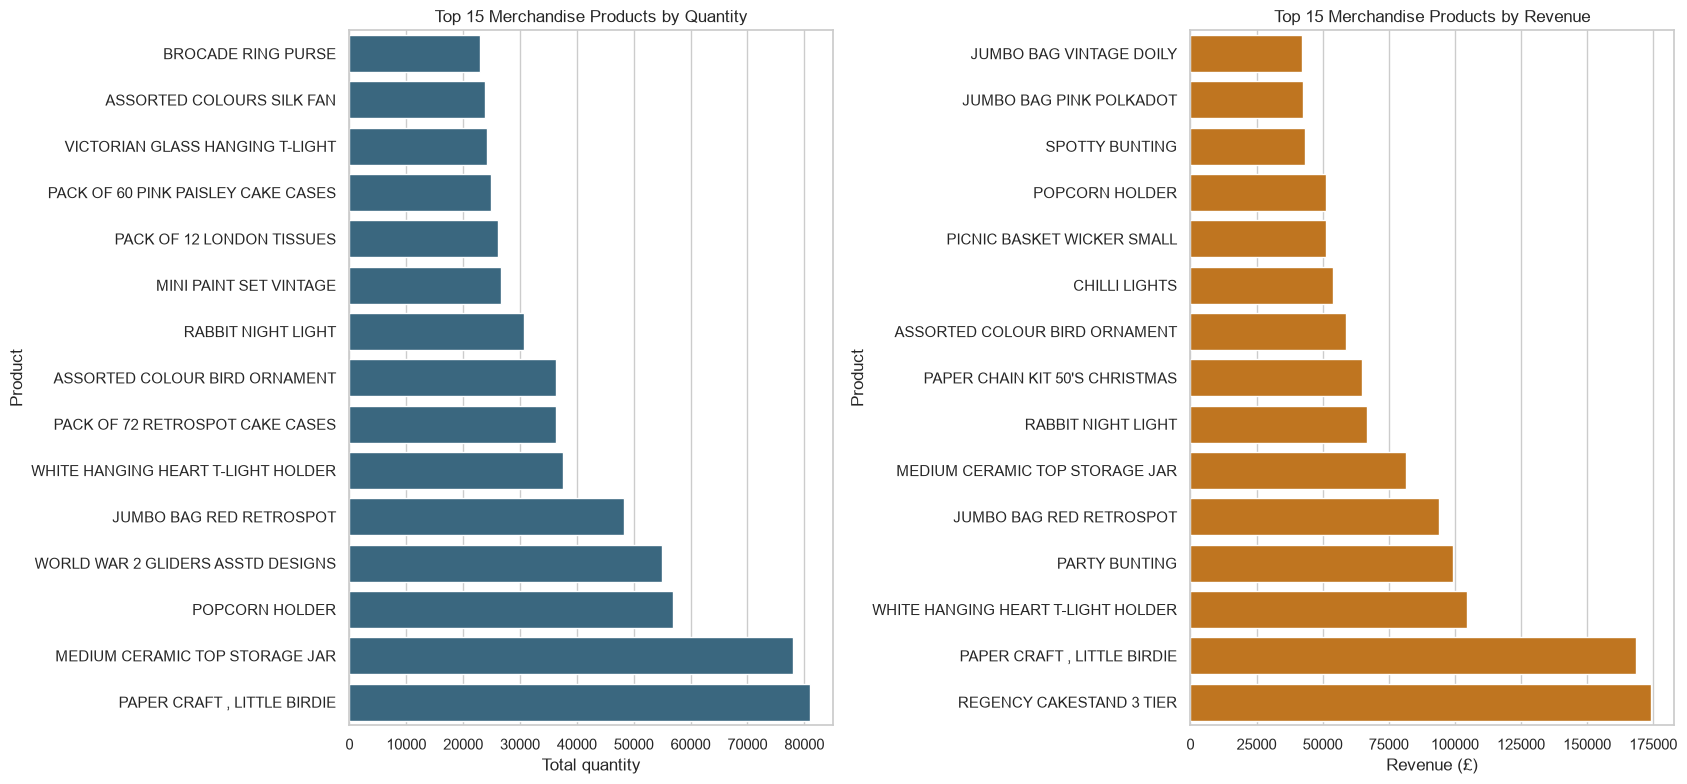

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(17, 8))

quantity_chart_data = (
    top_products_quantity
    .sort_values("Total_Quantity")
)

revenue_chart_data = (
    top_products_revenue
    .sort_values("Total_Revenue")
)

sns.barplot(
    data=quantity_chart_data,
    x="Total_Quantity",
    y="Canonical_Description",
    ax=axes[0],
    color="#2F6B8A"
)
axes[0].set_title("Top 15 Merchandise Products by Quantity")
axes[0].set_xlabel("Total quantity")
axes[0].set_ylabel("Product")

sns.barplot(
    data=revenue_chart_data,
    x="Total_Revenue",
    y="Canonical_Description",
    ax=axes[1],
    color="#D97706"
)
axes[1].set_title("Top 15 Merchandise Products by Revenue")
axes[1].set_xlabel("Revenue (£)")
axes[1].set_ylabel("Product")

plt.tight_layout()
plt.show()

In [51]:
total_merchandise_revenue = product_summary["Total_Revenue"].sum()
total_merchandise_quantity = product_summary["Total_Quantity"].sum()

product_concentration = pd.Series({
    "Top 1 product revenue share (%)": (
        product_summary.nlargest(1, "Total_Revenue")["Total_Revenue"].sum()
        / total_merchandise_revenue * 100
    ),
    "Top 10 products revenue share (%)": (
        product_summary.nlargest(10, "Total_Revenue")["Total_Revenue"].sum()
        / total_merchandise_revenue * 100
    ),
    "Top 20 products revenue share (%)": (
        product_summary.nlargest(20, "Total_Revenue")["Total_Revenue"].sum()
        / total_merchandise_revenue * 100
    ),
    "Top 10 products quantity share (%)": (
        product_summary.nlargest(10, "Total_Quantity")["Total_Quantity"].sum()
        / total_merchandise_quantity * 100
    )
}).to_frame("Percentage")

display(product_concentration.round(2))

,Percentage
Top 1 product revenue share (%),1.70
Top 10 products revenue share (%),9.44
Top 20 products revenue share (%),13.54
Top 10 products quantity share (%),8.76


In [52]:
description_consistency = (
    merchandise_candidate_df
    .assign(
        Clean_Description=lambda data: (
            data["Description"]
            .astype("string")
            .str.strip()
            .str.upper()
        )
    )
    .groupby("StockCode")
    .agg(
        Description_Variants=(
            "Clean_Description",
            lambda values: values.dropna().nunique()
        ),
        Example_Descriptions=(
            "Clean_Description",
            lambda values: " | ".join(
                values.dropna().drop_duplicates().head(3)
            )
        )
    )
    .reset_index()
    .sort_values(
        "Description_Variants",
        ascending=False
    )
)

multiple_description_codes = description_consistency.loc[
    description_consistency["Description_Variants"] > 1
]

print(
    "StockCodes with multiple cleaned descriptions:",
    f"{len(multiple_description_codes):,}"
)
print(
    "Maximum descriptions for one StockCode:",
    description_consistency["Description_Variants"].max()
)

display(multiple_description_codes.head(15))

StockCodes with multiple cleaned descriptions: 217
Maximum descriptions for one StockCode: 4


,StockCode,Description_Variants,Example_Descriptions
2014,23236,4,DOILEY STORAGE TIN | DOILEY BISCUIT TIN | STOR...
1974,23196,4,RETRO LEAVES MAGNETIC NOTEPAD | RETO LEAVES MA...
2022,23244,3,ROUND STORAGE TIN VINTAGE LEAF | STORAGE TIN V...
2170,23413,3,VINTAGE COFFEE GRINDER BOX | DECROTIVEVINTAGE ...
1910,23131,3,MISTLETOE HEART WREATH CREAM | MISELTOE HEART ...
2931,17107D,3,"FLOWER FAIRY,5 SUMMER B'DRAW LINERS | FLOWER F..."
2153,23396,3,BUTTERFLY CUSHION COVER | LA JARDIN BOTANIQUE ...
2009,23231,3,WRAP DOILEY DESIGN | WRAP VINTAGE DOILEY | WR...
1987,23209,3,LUNCH BAG DOILEY PATTERN | LUNCH BAG VINTAGE D...
1573,22776,3,"SWEETHEART CAKESTAND 3 TIER | CAKESTAND, 3 TIE..."


### Product Analysis Interpretation

Product rankings by quantity and revenue measure different forms of importance. High-quantity products may be inexpensive frequently purchased items, while high-revenue products may reflect premium items or unusually large wholesale orders.

Extreme single invoices can strongly affect total product quantity and revenue. Therefore, rankings should be interpreted together with invoice counts and customer counts rather than total value alone.

Some stock codes may have multiple description variants. Association-rule mining should use `StockCode` as the item identifier and use a documented canonical description only for human-readable reporting. Product descriptions should not be treated as independent products.


## 10. Preliminary Customer Purchasing Behaviour

Customer-level purchasing behaviour is examined using valid, deduplicated, identified-customer merchandise transactions. This is an exploratory customer profile rather than the final feature-engineering dataset.

Recency, frequency and monetary measures are calculated provisionally to understand their distributions. Final feature definitions and sensitivity decisions will be documented during feature engineering.

In [53]:
customer_eda_source = (
    merchandise_candidate_df.loc[
        merchandise_candidate_df["CustomerID"].notna()
    ]
    .copy()
)

customer_eda_source["CustomerID"] = (
    customer_eda_source["CustomerID"].astype("int64")
)

analysis_date = (
    customer_eda_source["InvoiceDate"].max().normalize()
    + pd.Timedelta(days=1)
)

customer_eda_summary = (
    customer_eda_source
    .groupby("CustomerID")
    .agg(
        Last_Purchase=("InvoiceDate", "max"),
        First_Purchase=("InvoiceDate", "min"),
        Frequency=("InvoiceNo", "nunique"),
        Monetary=("LineTotal", "sum"),
        Total_Quantity=("Quantity", "sum"),
        Product_Diversity=("StockCode", "nunique"),
        Transaction_Rows=("InvoiceNo", "size"),
        Primary_Country=(
            "Country",
            lambda values: values.mode().iloc[0]
        )
    )
)

customer_eda_summary["Recency"] = (
    analysis_date
    - customer_eda_summary["Last_Purchase"].dt.normalize()
).dt.days

customer_eda_summary["Tenure_Days"] = (
    customer_eda_summary["Last_Purchase"].dt.normalize()
    - customer_eda_summary["First_Purchase"].dt.normalize()
).dt.days

customer_eda_summary["Average_Order_Value"] = (
    customer_eda_summary["Monetary"]
    / customer_eda_summary["Frequency"]
)

print(f"Analysis date          : {analysis_date.date()}")
print(f"Customers represented  : {len(customer_eda_summary):,}")
print(f"Source transaction rows: {len(customer_eda_source):,}")

display(customer_eda_summary.head())

Analysis date          : 2011-12-10
Customers represented  : 4,334
Source transaction rows: 391,150


,Last_Purchase,First_Purchase,Frequency,Monetary,Total_Quantity,Product_Diversity,Transaction_Rows,Primary_Country,Recency,Tenure_Days,Average_Order_Value
CustomerID,,,,,,,,,,,
12346,2011-01-18 10:01:00,2011-01-18 10:01:00,1,"77,183.60",74215,1,1,United Kingdom,326,0,"77,183.60"
12347,2011-12-07 15:52:00,2010-12-07 14:57:00,7,"4,310.00",2458,103,182,Iceland,3,365,615.71
12348,2011-09-25 13:13:00,2010-12-16 19:09:00,4,"1,437.24",2332,21,27,Finland,76,283,359.31
12349,2011-11-21 09:51:00,2011-11-21 09:51:00,1,"1,457.55",630,72,72,Italy,19,0,"1,457.55"
12350,2011-02-02 16:01:00,2011-02-02 16:01:00,1,294.40,196,16,16,Norway,311,0,294.40


In [54]:
customer_feature_summary = customer_eda_summary[
    [
        "Recency",
        "Frequency",
        "Monetary",
        "Total_Quantity",
        "Product_Diversity",
        "Average_Order_Value",
        "Tenure_Days"
    ]
].describe(
    percentiles=[
        0.01, 0.05, 0.25, 0.50,
        0.75, 0.90, 0.95, 0.99
    ]
).T

display(customer_feature_summary)

,count,mean,std,min,1%,5%,25%,50%,75%,90%,95%,99%,max
Recency,"4,334.00",93.23,100.18,1.00,2.00,3.00,18.00,51.00,143.00,264.00,312.00,369.00,374.00
Frequency,"4,334.00",4.25,7.63,1.00,1.00,1.00,1.00,2.00,5.00,9.00,13.00,30.00,206.00
Monetary,"4,334.00","2,015.97","8,903.67",3.75,52.20,110.96,304.24,662.57,"1,631.62","3,560.08","5,735.22","18,715.31","279,138.02"
Total_Quantity,"4,334.00","1,186.38","5,040.62",1.00,12.33,46.00,159.25,377.50,989.75,"2,109.70","3,555.70","10,887.79","196,844.00"
Product_Diversity,"4,334.00",61.43,85.31,1.00,1.00,4.00,16.00,35.00,77.00,142.70,204.00,353.67,"1,785.00"
Average_Order_Value,"4,334.00",415.48,"1,800.90",3.75,43.67,89.85,177.20,289.56,423.41,657.79,915.34,"2,023.78","84,236.25"
Tenure_Days,"4,334.00",130.61,132.26,0.00,0.00,0.00,0.00,92.50,252.00,339.70,357.00,368.00,373.00


In [55]:
customer_frequency_summary = pd.Series({
    "Customers with exactly one purchase invoice": (
        customer_eda_summary["Frequency"] == 1
    ).sum(),
    "Customers with multiple purchase invoices": (
        customer_eda_summary["Frequency"] > 1
    ).sum(),
    "One-purchase customer percentage": (
        (customer_eda_summary["Frequency"] == 1).mean() * 100
    ),
    "Repeat-customer percentage": (
        (customer_eda_summary["Frequency"] > 1).mean() * 100
    ),
    "Customers purchasing within last 30 days": (
        customer_eda_summary["Recency"] <= 30
    ).sum(),
    "Customers inactive for more than 180 days": (
        customer_eda_summary["Recency"] > 180
    ).sum()
}).to_frame("Value")

display(customer_frequency_summary.round(2))

,Value
Customers with exactly one purchase invoice,"1,505.00"
Customers with multiple purchase invoices,"2,829.00"
One-purchase customer percentage,34.73
Repeat-customer percentage,65.27
Customers purchasing within last 30 days,"1,627.00"
Customers inactive for more than 180 days,863.00


In [56]:
customer_revenue_ranked = (
    customer_eda_summary
    .sort_values("Monetary", ascending=False)
    .copy()
)

total_customer_revenue = customer_revenue_ranked["Monetary"].sum()
number_of_customers = len(customer_revenue_ranked)

top_1_percent_count = max(
    1,
    int(np.ceil(number_of_customers * 0.01))
)

top_10_percent_count = max(
    1,
    int(np.ceil(number_of_customers * 0.10))
)

customer_revenue_concentration = pd.Series({
    "Top customer revenue share (%)": (
        customer_revenue_ranked.iloc[0]["Monetary"]
        / total_customer_revenue * 100
    ),
    "Top 1% customers revenue share (%)": (
        customer_revenue_ranked
        .head(top_1_percent_count)["Monetary"]
        .sum()
        / total_customer_revenue * 100
    ),
    "Top 10% customers revenue share (%)": (
        customer_revenue_ranked
        .head(top_10_percent_count)["Monetary"]
        .sum()
        / total_customer_revenue * 100
    )
}).to_frame("Percentage")

display(customer_revenue_concentration.round(2))

,Percentage
Top customer revenue share (%),3.19
Top 1% customers revenue share (%),32.20
Top 10% customers revenue share (%),61.42


In [57]:
display(
    customer_revenue_ranked[
        [
            "Recency",
            "Frequency",
            "Monetary",
            "Total_Quantity",
            "Product_Diversity",
            "Average_Order_Value",
            "Tenure_Days",
            "Primary_Country"
        ]
    ].head(15)
)

,Recency,Frequency,Monetary,Total_Quantity,Product_Diversity,Average_Order_Value,Tenure_Days,Primary_Country
CustomerID,,,,,,,,
14646,2,72,"279,138.02",196844,699,"3,876.92",353,Netherlands
18102,1,60,"259,657.30",64124,150,"4,327.62",367,United Kingdom
17450,9,46,"194,390.79",69973,124,"4,225.89",359,United Kingdom
16446,1,2,"168,472.50",80997,3,"84,236.25",205,United Kingdom
14911,2,198,"136,161.83",80154,1785,687.69,372,EIRE
12415,25,20,"124,564.53",77373,443,"6,228.23",313,Australia
14156,10,54,"116,560.08",57755,713,"2,158.52",362,EIRE
17511,3,31,"91,062.38",64549,453,"2,937.50",371,United Kingdom
12346,326,1,"77,183.60",74215,1,"77,183.60",0,United Kingdom


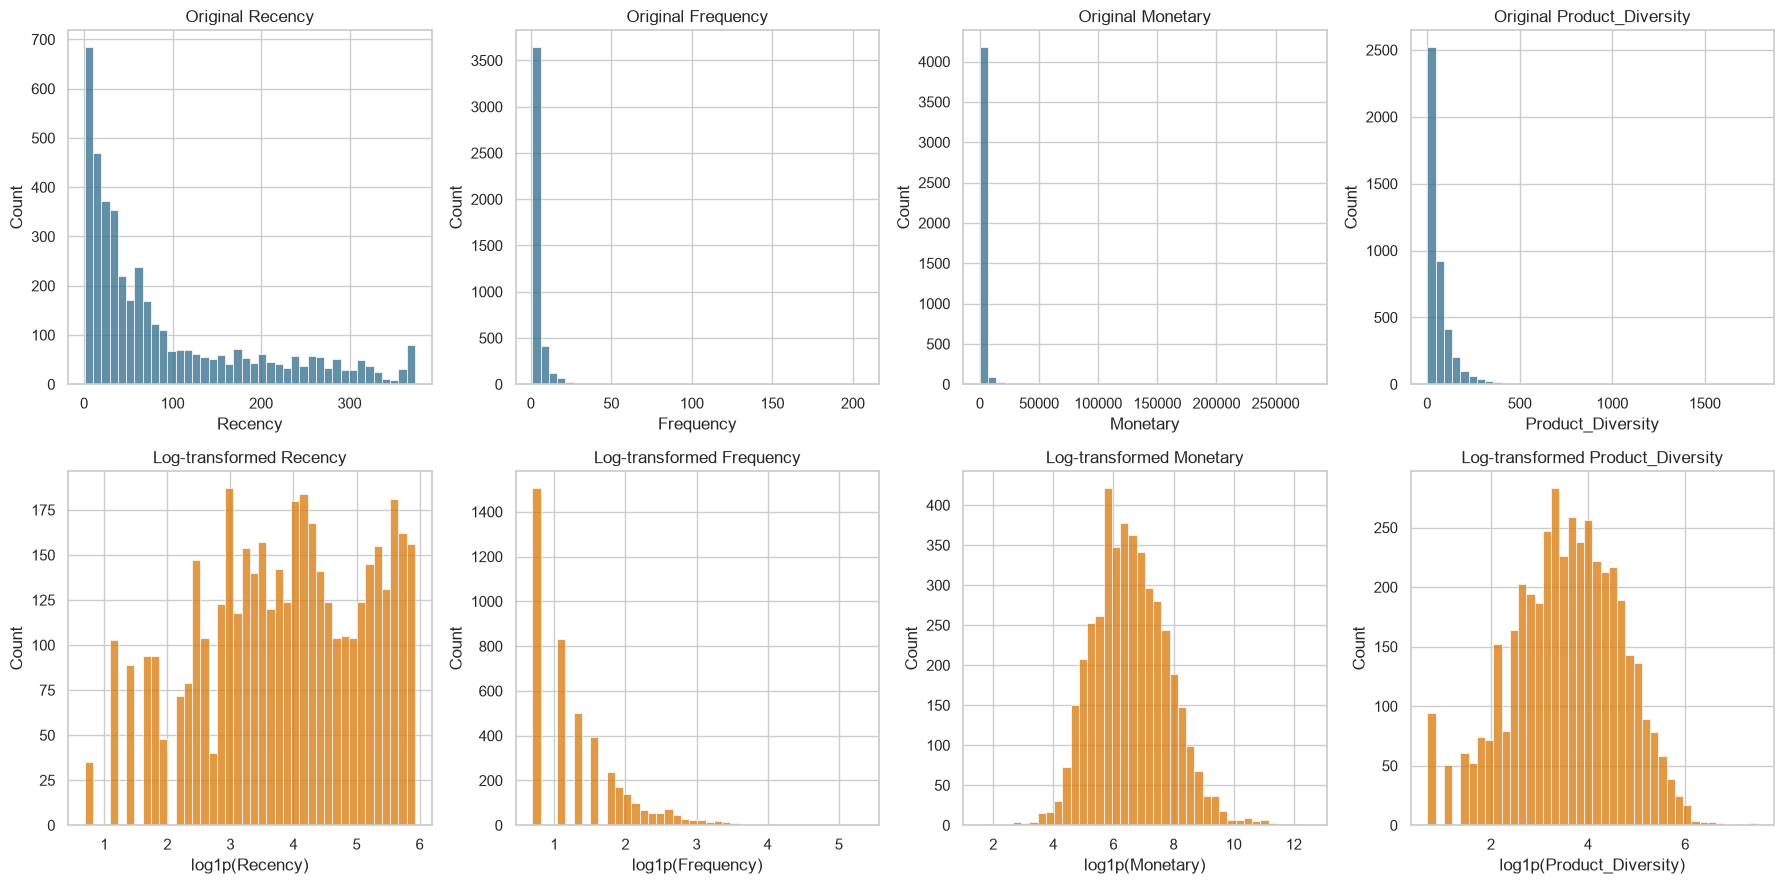

In [58]:
features_to_plot = [
    "Recency",
    "Frequency",
    "Monetary",
    "Product_Diversity"
]

fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for index, feature in enumerate(features_to_plot):
    sns.histplot(
        customer_eda_summary[feature],
        bins=40,
        ax=axes[0, index],
        color="#2F6B8A"
    )
    axes[0, index].set_title(f"Original {feature}")

    sns.histplot(
        np.log1p(customer_eda_summary[feature]),
        bins=40,
        ax=axes[1, index],
        color="#D97706"
    )
    axes[1, index].set_title(f"Log-transformed {feature}")
    axes[1, index].set_xlabel(f"log1p({feature})")

plt.tight_layout()
plt.show()

### Customer-Behaviour Interpretation

Preliminary customer-level measures show differences in purchase recency, invoice frequency, spending, quantities and product diversity. These variations support the suitability of customer segmentation for this dataset.

Frequency is measured using distinct purchase invoices rather than transaction rows because one invoice can contain multiple product lines. Monetary value is based on valid deduplicated merchandise purchases in this exploratory profile.

Customers with only one observed purchase invoice should be described as one-purchase customers within the available observation period, not necessarily first-time customers. Similarly, customers with high recency show dormant or potentially at-risk behaviour, but the dataset does not contain a confirmed churn label.

Strongly skewed customer features and revenue concentration may cause distance-based clustering to be dominated by a small number of high-value wholesale customers. Log transformation, robust scaling, outlier sensitivity and cluster stability must therefore be evaluated before selecting the final model.

In [60]:
data_dictionary = pd.DataFrame([
    {
        "Variable": "InvoiceNo",
        "Description": "Unique invoice identifier; C prefix indicates cancellation",
        "Data Type": "Categorical identifier",
        "Analysis Role": "Basket identifier",
        "Quality Issue": "Contains cancellation invoices"
    },
    {
        "Variable": "StockCode",
        "Description": "Unique product or administrative item code",
        "Data Type": "Categorical identifier",
        "Analysis Role": "Product identifier",
        "Quality Issue": "Includes fees, postage and manual adjustment codes"
    },
    {
        "Variable": "Description",
        "Description": "Human-readable product description",
        "Data Type": "Categorical text",
        "Analysis Role": "Product interpretation",
        "Quality Issue": "1,454 missing values and multiple descriptions for some StockCodes"
    },
    {
        "Variable": "Quantity",
        "Description": "Number of units recorded for the invoice line",
        "Data Type": "Integer",
        "Analysis Role": "Transaction measure",
        "Quality Issue": "Negative returns/adjustments and extreme wholesale values"
    },
    {
        "Variable": "InvoiceDate",
        "Description": "Date and time of invoice transaction",
        "Data Type": "Datetime",
        "Analysis Role": "Temporal and recency measure",
        "Quality Issue": "December 2011 is incomplete"
    },
    {
        "Variable": "UnitPrice",
        "Description": "Price per unit in pounds sterling",
        "Data Type": "Continuous numeric",
        "Analysis Role": "Revenue calculation",
        "Quality Issue": "Zero, negative and extreme values"
    },
    {
        "Variable": "CustomerID",
        "Description": "Unique customer identifier",
        "Data Type": "Categorical identifier",
        "Analysis Role": "Customer grouping key",
        "Quality Issue": "135,080 missing values; imported as float due to missingness"
    },
    {
        "Variable": "Country",
        "Description": "Country associated with the customer transaction",
        "Data Type": "Categorical",
        "Analysis Role": "Geographic interpretation",
        "Quality Issue": "Strong United Kingdom dominance"
    }
])

display(data_dictionary)

,Variable,Description,Data Type,Analysis Role,Quality Issue
0,InvoiceNo,Unique invoice identifier; C prefix indicates ...,Categorical identifier,Basket identifier,Contains cancellation invoices
1,StockCode,Unique product or administrative item code,Categorical identifier,Product identifier,"Includes fees, postage and manual adjustment c..."
2,Description,Human-readable product description,Categorical text,Product interpretation,"1,454 missing values and multiple descriptions..."
3,Quantity,Number of units recorded for the invoice line,Integer,Transaction measure,Negative returns/adjustments and extreme whole...
4,InvoiceDate,Date and time of invoice transaction,Datetime,Temporal and recency measure,December 2011 is incomplete
5,UnitPrice,Price per unit in pounds sterling,Continuous numeric,Revenue calculation,"Zero, negative and extreme values"
6,CustomerID,Unique customer identifier,Categorical identifier,Customer grouping key,"135,080 missing values; imported as float due ..."
7,Country,Country associated with the customer transaction,Categorical,Geographic interpretation,Strong United Kingdom dominance


In [61]:
eda_insight_log = pd.DataFrame([
    {
        "ID": "EDA01",
        "Topic": "Missing CustomerID",
        "Evidence": "135,080 rows (24.93%) have missing CustomerID",
        "Business Meaning": "A substantial share of transactions cannot be linked to identified customers",
        "Modelling Impact": "Exclude these rows from customer segmentation and segment-specific rules",
        "Limitation": "Anonymous purchasing behaviour will not be represented in customer segments"
    },
    {
        "ID": "EDA02",
        "Topic": "Missing Description",
        "Evidence": "1,454 descriptions are missing; every such row also lacks CustomerID",
        "Business Meaning": "These records provide limited product and customer interpretation",
        "Modelling Impact": "Exclude from merchandise-level analysis after preserving raw evidence",
        "Limitation": "Some inventory activity may be removed"
    },
    {
        "ID": "EDA03",
        "Topic": "Exact duplicates",
        "Evidence": "5,268 additional exact duplicate rows (0.97%)",
        "Business Meaning": "Repeated records could inflate sales and product frequency",
        "Modelling Impact": "Retain one copy during preprocessing and record before/after counts",
        "Limitation": "No line-level identifier exists to prove whether every repetition is erroneous"
    },
    {
        "ID": "EDA04",
        "Topic": "Cancellations and returns",
        "Evidence": "9,288 cancellation rows; 10,624 negative-quantity rows",
        "Business Meaning": "The dataset contains cancellations, returns and stock adjustments",
        "Modelling Impact": "Exclude from purchase-only RFM but preserve separately for return analysis",
        "Limitation": "Not every negative quantity has a C-prefixed invoice"
    },
    {
        "ID": "EDA05",
        "Topic": "Invalid purchase prices",
        "Evidence": "2 negative-price and 2,515 zero-price rows",
        "Business Meaning": "These rows cannot represent normal positive sales revenue",
        "Modelling Impact": "Exclude from purchase-only monetary calculations",
        "Limitation": "Some zero-price records may represent samples or internal adjustments"
    },
    {
        "ID": "EDA06",
        "Topic": "Administrative StockCodes",
        "Evidence": "2,310 candidate administrative rows worth £394,205.67",
        "Business Meaning": "Fees, postage and manual adjustments are mixed with merchandise",
        "Modelling Impact": "Exclude from product association rules; test monetary sensitivity",
        "Limitation": "Some charges may represent genuine customer expenditure"
    },
    {
        "ID": "EDA07",
        "Topic": "Extreme purchasing values",
        "Evidence": "Maximum valid line total is £168,469.60; maximum quantity is 80,995",
        "Business Meaning": "Wholesale or exceptional transactions strongly affect totals",
        "Modelling Impact": "Compare raw, log-transformed and robustly scaled customer features",
        "Limitation": "Statistical outliers are not necessarily data errors"
    },
    {
        "ID": "EDA08",
        "Topic": "Geographic imbalance",
        "Evidence": "UK represents 91.45% of valid rows and 84.59% of revenue",
        "Business Meaning": "Results primarily describe the UK customer base",
        "Modelling Impact": "Do not automatically encode Country; consider UK-only sensitivity",
        "Limitation": "Segments may not generalise equally to smaller countries"
    },
    {
        "ID": "EDA09",
        "Topic": "Incomplete final month",
        "Evidence": "December 2011 contains transactions only from 01 to 09 December",
        "Business Meaning": "December 2011 monthly totals are incomplete",
        "Modelling Impact": "Flag the month and avoid direct full-month comparison",
        "Limitation": "The dataset does not cover a complete second December"
    },
    {
        "ID": "EDA10",
        "Topic": "Product-description inconsistency",
        "Evidence": "217 StockCodes have multiple cleaned descriptions",
        "Business Meaning": "Descriptions changed or contain spelling/naming variations",
        "Modelling Impact": "Use StockCode as item ID and canonical description for reporting",
        "Limitation": "Canonical labels may hide historical description changes"
    },
    {
        "ID": "EDA11",
        "Topic": "Customer purchasing frequency",
        "Evidence": "34.73% have one invoice; 65.27% have multiple invoices",
        "Business Meaning": "The observed customer base includes both one-purchase and repeat buyers",
        "Modelling Impact": "Frequency is a useful segmentation feature",
        "Limitation": "One observed invoice does not prove a customer is genuinely new"
    },
    {
        "ID": "EDA12",
        "Topic": "Customer revenue concentration",
        "Evidence": "Top 1% generate 32.20%; top 10% generate 61.42% of merchandise revenue",
        "Business Meaning": "A small high-value customer group contributes much of the revenue",
        "Modelling Impact": "Test transformations, scaling and outlier sensitivity",
        "Limitation": "High-value customers may include wholesalers"
    }
])

display(eda_insight_log)

,ID,Topic,Evidence,Business Meaning,Modelling Impact,Limitation
0,EDA01,Missing CustomerID,"135,080 rows (24.93%) have missing CustomerID",A substantial share of transactions cannot be ...,Exclude these rows from customer segmentation ...,Anonymous purchasing behaviour will not be rep...
1,EDA02,Missing Description,"1,454 descriptions are missing; every such row...",These records provide limited product and cust...,Exclude from merchandise-level analysis after ...,Some inventory activity may be removed
2,EDA03,Exact duplicates,"5,268 additional exact duplicate rows (0.97%)",Repeated records could inflate sales and produ...,Retain one copy during preprocessing and recor...,No line-level identifier exists to prove wheth...
3,EDA04,Cancellations and returns,"9,288 cancellation rows; 10,624 negative-quant...","The dataset contains cancellations, returns an...",Exclude from purchase-only RFM but preserve se...,Not every negative quantity has a C-prefixed i...
4,EDA05,Invalid purchase prices,"2 negative-price and 2,515 zero-price rows",These rows cannot represent normal positive sa...,Exclude from purchase-only monetary calculations,Some zero-price records may represent samples ...
5,EDA06,Administrative StockCodes,"2,310 candidate administrative rows worth £394...","Fees, postage and manual adjustments are mixed...",Exclude from product association rules; test m...,Some charges may represent genuine customer ex...
6,EDA07,Extreme purchasing values,"Maximum valid line total is £168,469.60; maxim...",Wholesale or exceptional transactions strongly...,"Compare raw, log-transformed and robustly scal...",Statistical outliers are not necessarily data ...
7,EDA08,Geographic imbalance,UK represents 91.45% of valid rows and 84.59% ...,Results primarily describe the UK customer base,Do not automatically encode Country; consider ...,Segments may not generalise equally to smaller...
8,EDA09,Incomplete final month,December 2011 contains transactions only from ...,December 2011 monthly totals are incomplete,Flag the month and avoid direct full-month com...,The dataset does not cover a complete second D...
9,EDA10,Product-description inconsistency,217 StockCodes have multiple cleaned descriptions,Descriptions changed or contain spelling/namin...,Use StockCode as item ID and canonical descrip...,Canonical labels may hide historical descripti...


In [62]:
documentation_path = project_root / "documentation"
tables_path = project_root / "outputs" / "tables"

documentation_path.mkdir(parents=True, exist_ok=True)
tables_path.mkdir(parents=True, exist_ok=True)

data_dictionary.to_csv(
    documentation_path / "data_dictionary.csv",
    index=False
)

eda_insight_log.to_csv(
    documentation_path / "eda_insight_log.csv",
    index=False
)

missing_summary.to_csv(
    tables_path / "missing_value_summary.csv"
)

transaction_quality_summary.to_csv(
    tables_path / "transaction_quality_summary.csv"
)

country_summary.to_csv(
    tables_path / "country_summary.csv",
    index=False
)

monthly_summary.to_csv(
    tables_path / "monthly_summary.csv",
    index=False
)

product_summary.to_csv(
    tables_path / "product_summary.csv",
    index=False
)

customer_feature_summary.to_csv(
    tables_path / "customer_feature_summary.csv"
)

print("EDA documentation and summary tables saved successfully.")

EDA documentation and summary tables saved successfully.


In [63]:
assert len(df) == 541_909
assert df.shape[1] == 8
assert df.duplicated().sum() == 5_268
assert df["CustomerID"].isna().sum() == 135_080
assert df["Description"].isna().sum() == 1_454
assert is_cancellation.sum() == 9_288
assert is_negative_quantity.sum() == 10_624
assert is_non_positive_price.sum() == 2_517
assert actual_sha256 == EXPECTED_SHA256
assert len(customer_eda_summary) == 4_334

print("All Data Understanding and EDA quality checks passed.")

All Data Understanding and EDA quality checks passed.


## Data Understanding and EDA Conclusion

The Online Retail dataset is suitable for customer segmentation and segment-specific product association analysis, but it cannot be modelled responsibly without task-specific preprocessing.

The principal issues are missing customer identifiers, exact duplicates, cancellations, negative quantities, zero or negative prices, administrative stock codes, extreme wholesale behaviour, geographic imbalance, inconsistent product descriptions and an incomplete final month.

A single cleaned dataset is not appropriate for every task. The project will therefore create separate analytical datasets:

1. **Customer-feature dataset** — valid, identified-customer purchase behaviour for segmentation.
2. **Purchase-basket dataset** — valid merchandise invoice-product combinations for association mining.
3. **Returns dataset** — cancellation and negative-quantity records retained for separate investigation.
4. **Sensitivity datasets** — alternative customer features for assessing administrative records and extreme-value treatment.

All preprocessing decisions will be recorded with their reasons, evidence and before-and-after row counts.